# Module 02 — anemoi-datasets: Creating and Working with Training Datasets

**Module 02 of "Machine Learning for Earth System Modeling: the Anemoi framework"** · BSC AI Factory

This notebook accompanies the Module 02 presentation. It covers:
1. Inspecting a finished anemoi-datasets zarr store
2. Creating a dataset downloading data from the mars catalogue
3. Creating datasets from local GRIB and NetCDF sources (ERA5 and CERRA)
4. The modular build workflow: `init` / `load` / `finalise`
5. Reading, subsetting, and combining datasets with `open_dataset`
6. Validation and best practices

---
## Setup

This notebook runs in an environment with the following packages:

| Package | Role |
|---|---|
| anemoi-datasets | dataset creation CLI + `open_dataset` read API |
| anemoi-transform | field filters used inside recipes |
| anemoi-utils | shared date/grid utilities |
| eccodes | GRIB decoding |
| ecmwf-opendata | ECMWF open-data GRIB download |

> **Demo data:** the `data/` directory is not tracked in the repository. Download it from the source specified in the README and place it in the project root before running any cell below.

In [88]:
import os
from pathlib import Path

# Set working directory to the repo root
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(root)
(root / "data" / "derived" / "module-02").mkdir(parents=True, exist_ok=True)  # outputs built in this notebook
print(f"Working directory: {root}")

Working directory: /home/fdainell/Documents/climate-data-ai-anemoi


In [89]:
import importlib.metadata

packages = ["anemoi-datasets", "anemoi-transform", "anemoi-utils", "eccodes"]
for p in packages:
    print(f"{p:<22} {importlib.metadata.version(p)}")

anemoi-datasets        0.5.36
anemoi-transform       0.3.1
anemoi-utils           0.5.3
eccodes                2.47.0


---
## Section 1 — Inspecting an Existing Dataset

**Goal:** Before building anything, understand what a finished anemoi-datasets zarr store looks like from the outside.

We use the ERA5 O48 demo dataset (Jan–Jun 2020, 6-hourly, 43 variables).

### About this dataset

This is a reduced version of the variable set used in the ECMWF AIFS global model, designed to keep training costs manageable for regional and experimental models. Compared to the full AIFS configuration, which covers **13 pressure levels** (50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000 hPa), this demo includes only **4 pressure levels** (250, 500, 850, 1000 hPa).

The 43 variables fall into three functional categories:

| Category | Variables | Role in the model |
|---|---|---|
| **Prognostic** | `10u`, `10v`, `2d`, `2t`, `msl`, `skt`, `sp`, `tcw`, `q_{lev}`, `t_{lev}`, `u_{lev}`, `v_{lev}`, `z_{lev}` | Predicted at each step and fed back as input for the next step |
| **Diagnostic** | `cp`, `tp` | Predicted but **not** fed back — cannot drive the autoregressive rollout |
| **Forcing** | `cos/sin_julian_day`, `cos/sin_local_time`, `cos/sin_latitude`, `cos/sin_longitude`, `insolation`, `lsm`, `sdor`, `slor`, `z` | External inputs provided at every step, never predicted |

> **Prognostic vs diagnostic distinction:** precipitation (`tp`, `cp`) is diagnostic because feeding noisy short-range precipitation back into the model as an initial condition degrades forecast quality. Surface geopotential (`z`) is a static forcing — it encodes orography and is provided at every step but never predicted.

In [90]:
from anemoi.datasets import open_dataset

ERA5_O48 = "data/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1.zarr"

ds = open_dataset(ERA5_O48)

print(f"Shape:       {ds.shape}")         # (n_dates, n_variables, n_ensemble_members, n_gridpoints)
print(f"Variables:   {ds.variables}")
print(f"Dates:       {ds.dates[0]}  →  {ds.dates[-1]}")
print(f"Frequency:   {ds.frequency}")
print(f"Resolution:  {ds.resolution}")
print(f"Field shape: {ds.field_shape}")   # None for unstructured grids (O48 is reduced Gaussian)

Shape:       (728, 43, 1, 10944)
Variables:   ['10u', '10v', '2d', '2t', 'cos_julian_day', 'cos_latitude', 'cos_local_time', 'cos_longitude', 'cp', 'insolation', 'lsm', 'msl', 'q_1000', 'q_250', 'q_500', 'q_850', 'sdor', 'sin_julian_day', 'sin_latitude', 'sin_local_time', 'sin_longitude', 'skt', 'slor', 'sp', 't_1000', 't_250', 't_500', 't_850', 'tcw', 'tp', 'u_1000', 'u_250', 'u_500', 'u_850', 'v_1000', 'v_250', 'v_500', 'v_850', 'z', 'z_1000', 'z_250', 'z_500', 'z_850']
Dates:       2020-01-01T00:00:00  →  2020-06-30T18:00:00
Frequency:   6:00:00
Resolution:  O48
Field shape: (10944,)


In [91]:
# Indexing: each element is a (n_variables, n_ensemble_members, n_gridpoints) array
print("ds[0] shape:    ", ds[0].shape)    # first timestep
print("ds[-1] shape:   ", ds[-1].shape)   # last timestep
print("ds[0:3] shape:  ", ds[0:3].shape)  # slice of 3 timesteps

ds[0] shape:     (43, 1, 10944)
ds[-1] shape:    (43, 1, 10944)
ds[0:3] shape:   (3, 43, 1, 10944)


In [92]:
import numpy as np

stats = ds.statistics
print("Statistics keys:", list(stats.keys()))   # mean, stdev, minimum, maximum
print()

for var in ["2t", "tp"]:
    idx = ds.name_to_index[var]
    print(f"{var}:  mean={stats['mean'][idx]:.4f}  stdev={stats['stdev'][idx]:.4f}")

Statistics keys: ['mean', 'stdev', 'maximum', 'minimum']

2t:  mean=287.2216  stdev=16.5117
tp:  mean=0.0007  stdev=0.0026


Grid points: 10944


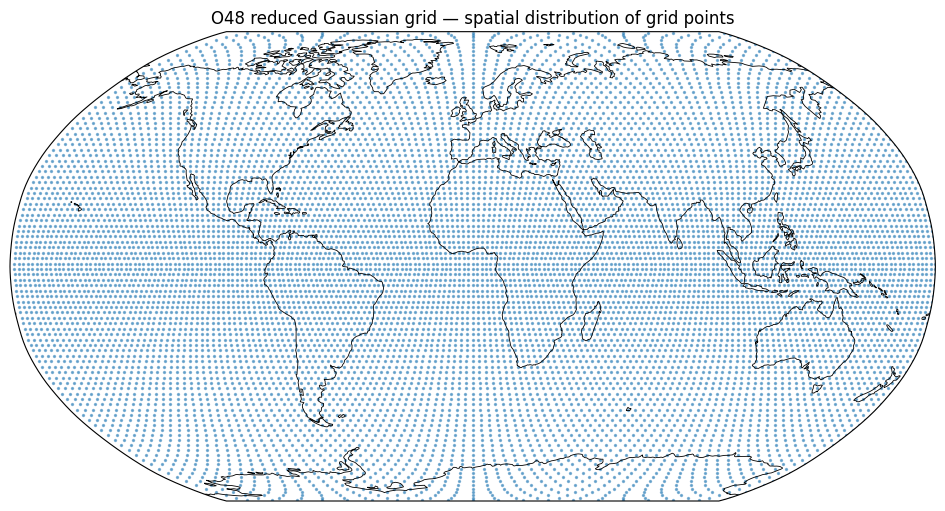

In [93]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

lons = ds.longitudes
lats = ds.latitudes
print(f"Grid points: {len(lons)}")

fig, ax = plt.subplots(figsize=(10, 5),
                       subplot_kw={"projection": ccrs.Robinson()},
                       constrained_layout=True)
ax.set_global()
ax.coastlines(resolution="110m", linewidth=0.6, color="black")
ax.scatter(lons, lats, s=2, alpha=0.5, transform=ccrs.PlateCarree())
ax.set_title("O48 reduced Gaussian grid — spatial distribution of grid points")
plt.show()

In [94]:
print("Missing dates:", ds.missing)
# An empty set means no missing timesteps in this dataset.
# A missing date is an entire row of NaNs, distinct from NaN values within a field.

Missing dates: set()


In [95]:
!anemoi-datasets inspect {ERA5_O48}

📦 Path          : data/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-06-30 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O48
🌎 Field shape: [10944]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 728 × 43 × 1 × 10,944 (1.3 GiB)
💽 Size       : 706.8 MiB (706.8 MiB)
📁 Files      : 753

   Index │ Variable       │          Min │        Max │        Mean │       Stdev
   ──────┼────────────────┼──────────────┼────────────┼─────────────┼────────────
       0 │ 10u            │     -31.1339 │    27.8938 │   -0.568336 │     5.43208
       1 │ 10v            │     -34.5802 │    29.6575 │  -0.0927517 │     4.51046
       2 │ 2d             │          198 │    302.976 │     282.147 │     16.3366
       3 │ 2t             │      201.357 │    320.262 │     287.222 │     16.5117
       4 │ cos_julian_day │    -0.800336 │          1 │    0.239709 │    0.589267
       5 │ cos_latitude   │    0.02

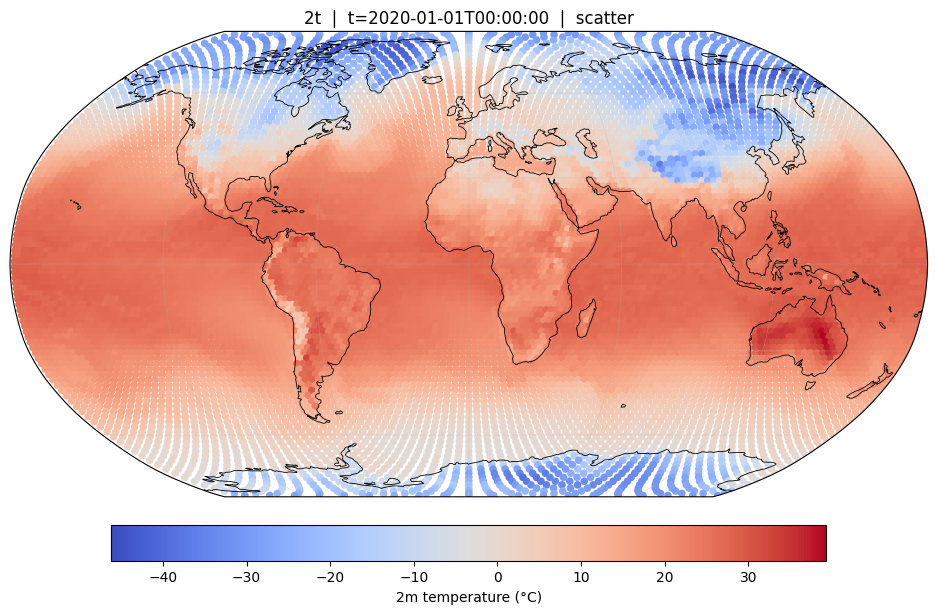

In [96]:
idx_2t = ds.name_to_index["2t"]
values_k = ds.data[0, idx_2t, 0, :]   # first timestep, all grid points
values_c = values_k - 273.15           # convert K → °C

fig, ax = plt.subplots(figsize=(12, 6),
                       subplot_kw={"projection": ccrs.Robinson()},
                       constrained_layout=True)
ax.set_global()
p = ax.scatter(lons, lats, c=values_c, s=30, cmap="coolwarm",
               transform=ccrs.PlateCarree(), rasterized=True, edgecolor="none")
ax.coastlines(resolution="110m", linewidth=0.6)
ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
plt.colorbar(p, ax=ax, orientation="horizontal", shrink=0.6,
             label="2m temperature (°C)")
ax.set_title(f"2t  |  t={ds.dates[0]}  |  scatter")
plt.show()

# Note: scatter is quick but markers overlap in dense regions and leave gaps at the poles.
# The tripcolor approach below gives a cleaner continuous field.

### Better rendering: Delaunay triangulation

For reduced Gaussian (O48, O96) and HEALPix grids the spatial dimension is irregular — grid points are not on a regular lat/lon grid. `ax.scatter` works but causes overlap/gap artifacts. `ax.tripcolor` with Delaunay triangulation renders the field as a continuous mesh, with no marker-size tuning needed.

The antimeridian mask (`spans > 180`) is required: without it, a band of artifacts crosses the globe where triangles span the date line.

In [97]:
import matplotlib.tri as mtri
import numpy as np

def _wrap_longitudes(longitudes):
    """Wrap longitudes to [-180, 180)."""
    return ((longitudes + 180.0) % 360.0) - 180.0

def build_triangulation(longitudes, latitudes):
    """Delaunay triangulation with antimeridian triangles masked out."""
    wrapped = _wrap_longitudes(longitudes)
    tri = mtri.Triangulation(wrapped, latitudes)
    spans = np.ptp(wrapped[tri.triangles], axis=1)
    tri.set_mask(spans > 180.0)
    return tri

def _build_projected_triangulation(lons, lats, projection):
    """Triangulation whose nodes are in projection coordinates.
    Reprojects each node to the target CRS after antimeridian masking."""
    tri_ll = build_triangulation(lons, lats)
    xy = projection.transform_points(ccrs.PlateCarree(), tri_ll.x, tri_ll.y)
    x_proj, y_proj = xy[:, 0], xy[:, 1]

    inf_mask = (
        ~np.all(np.isfinite(x_proj[tri_ll.triangles]), axis=1)
        | ~np.all(np.isfinite(y_proj[tri_ll.triangles]), axis=1)
    )
    base_mask = (
        tri_ll.mask if tri_ll.mask is not None
        else np.zeros(len(tri_ll.triangles), dtype=bool)
    )
    tri_proj = mtri.Triangulation(x_proj, y_proj, triangles=tri_ll.triangles)
    tri_proj.set_mask(base_mask | inf_mask)
    return tri_proj

def domain_mask(longitudes, latitudes, lon_bounds, lat_bounds):
    """Boolean mask for grid points inside the given lon/lat bounding box."""
    wrapped = _wrap_longitudes(longitudes)
    return (
        (wrapped >= lon_bounds[0]) & (wrapped <= lon_bounds[1])
        & (latitudes >= lat_bounds[0]) & (latitudes <= lat_bounds[1])
    )

def plot_variable(ds, var, timestep=0, lon_bounds=None, lat_bounds=None,
                  cmap="coolwarm", figsize=(12, 6),
                  projection=None, convert_kelvin=False):
    """Plot one variable from an anemoi dataset using tripcolor rendering."""
    idx = ds.name_to_index[var]
    lons = ds.longitudes.copy()
    lats = ds.latitudes.copy()
    values = ds.data[timestep, idx, 0, :]

    if lon_bounds and lat_bounds:
        mask = domain_mask(lons, lats, lon_bounds, lat_bounds)
        lons, lats, values = lons[mask], lats[mask], values[mask]

    if convert_kelvin:
        values = values - 273.15
        unit = "°C"
    else:
        unit = ""

    proj = projection if projection is not None else ccrs.PlateCarree()

    # Build triangulation in projection space — required for non-PlateCarree projections.
    # tripcolor is then called without transform= since nodes are already in display CRS.
    tri = _build_projected_triangulation(lons, lats, proj)

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": proj},
                           constrained_layout=True)
    mesh = ax.tripcolor(tri, values, shading="gouraud", cmap=cmap)
    ax.coastlines(resolution="110m", linewidth=0.6)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5, linestyle="--")

    if lon_bounds and lat_bounds:
        ax.set_extent([lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]],
                      crs=ccrs.PlateCarree())
    else:
        ax.set_global()

    cb_label = f"{var} ({unit})" if unit else var
    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.6,
                 label=cb_label)
    ax.set_title(f"{var}  |  t={ds.dates[timestep]}")
    return fig, ax

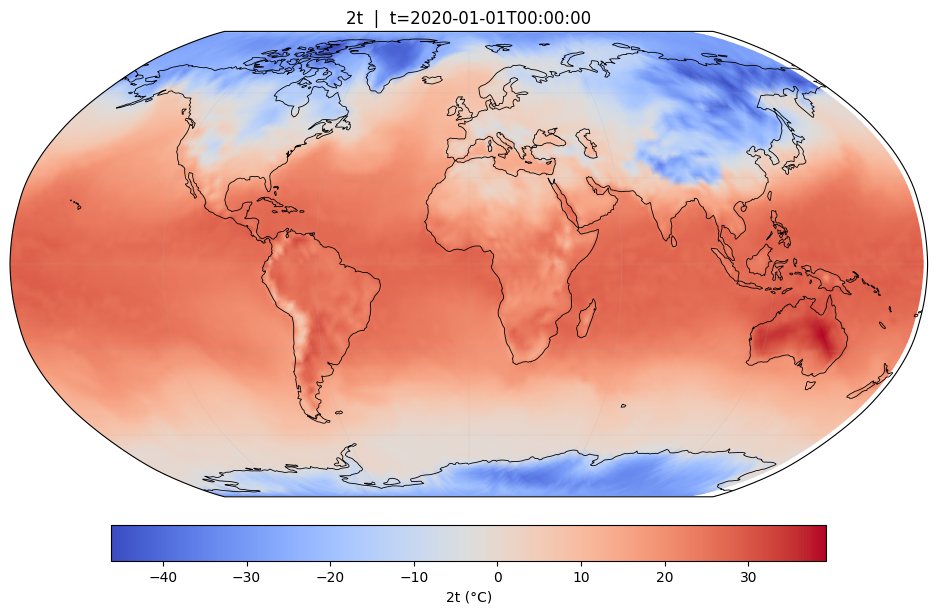

In [98]:
# Global map — O48 ERA5 2m temperature (Robinson projection, values in °C)
fig, ax = plot_variable(ds, "2t",
                        projection=ccrs.Robinson(central_longitude=0),
                        convert_kelvin=True)
plt.show()

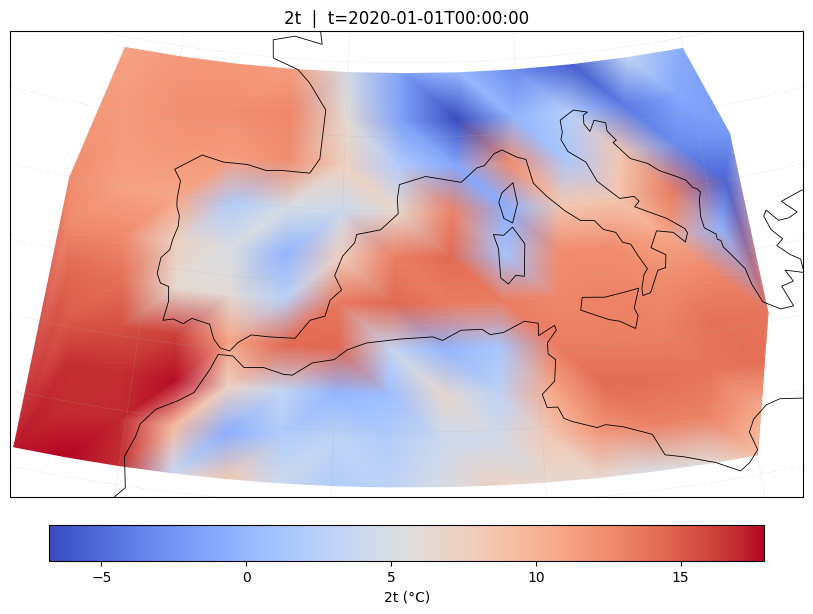

In [99]:
# Regional crop — western Mediterranean domain (Lambert Conformal, values in °C)
wmed_proj = ccrs.LambertConformal(
    central_longitude=3.5,    # midpoint of -15..22
    central_latitude=39.0,    # midpoint of 30..48
    standard_parallels=(30, 48),
)
fig, ax = plot_variable(ds, "2t",
                        lon_bounds=(-15, 22), lat_bounds=(30, 48),
                        projection=wmed_proj,
                        convert_kelvin=True)
plt.show()

### Temporal evolution at selected grid points

The spatial maps give a snapshot — a single timestep. To see the dataset's temporal dimension, we extract the full Jan–Jun 2020 time series for three grid points chosen to exhibit contrasting seasonal signals:

- **Iberian Peninsula** (~40°N, 4°W): mid-latitude continental, clear spring warming trend
- **Siberia** (~60°N, 90°E): continental interior, strong cold-season variability
- **Tropics** (~5°N, 20°E): equatorial Africa, small annual cycle with diurnal dominance

For each location we find the nearest O48 grid point by Euclidean distance in lon/lat space, then read the entire `2t` time series in one zarr access.

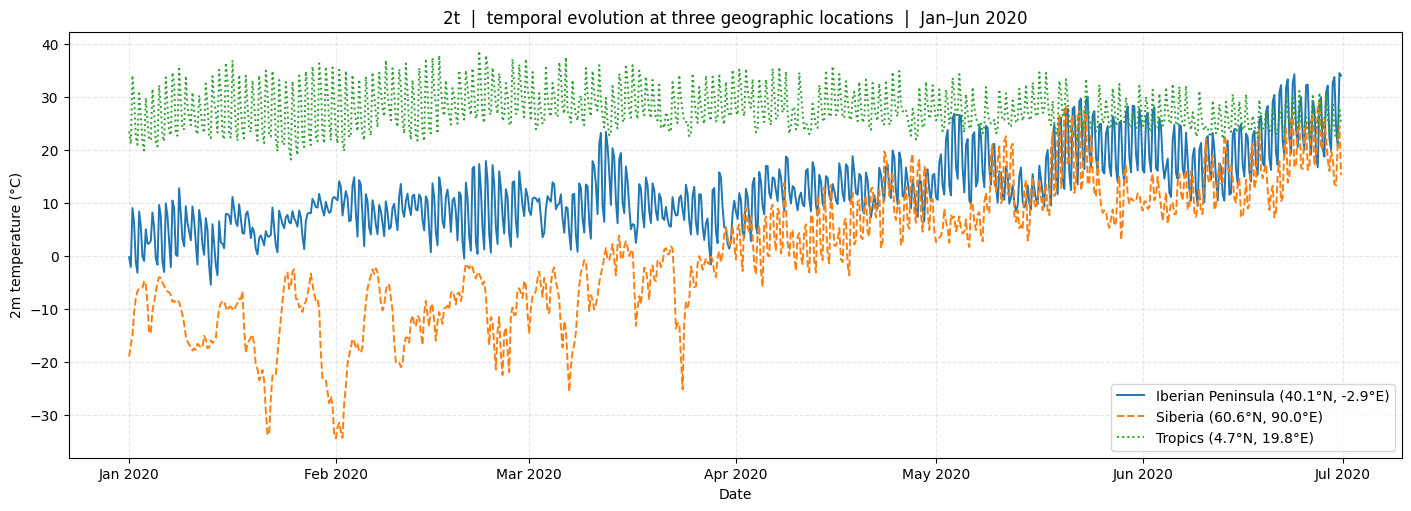

In [13]:
import matplotlib.dates as mdates

# Target locations: (label, target_lon, target_lat)
locations = [
    ("Iberian Peninsula", -4.0,  40.0),
    ("Siberia",           90.0,  60.0),
    ("Tropics",           20.0,   5.0),
]

def nearest_grid_point(longitudes, latitudes, target_lon, target_lat):
    """Return the index of the O48 grid point closest to (target_lon, target_lat)."""
    wrapped = _wrap_longitudes(longitudes)
    dist_sq = (wrapped - target_lon) ** 2 + (latitudes - target_lat) ** 2
    return int(np.argmin(dist_sq))

idx_2t = ds.name_to_index["2t"]
dates = ds.dates.astype("datetime64[ms]").astype("O")  # numpy datetime64 → Python datetime

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

linestyles = ["-", "--", ":"]
for (label, tlon, tlat), ls in zip(locations, linestyles):
    pt = nearest_grid_point(ds.longitudes, ds.latitudes, tlon, tlat)
    actual_lon = _wrap_longitudes(ds.longitudes)[pt]
    actual_lat = ds.latitudes[pt]
    ts = ds.data[:, idx_2t, 0, pt] - 273.15   # K → °C
    ax.plot(dates, ts, linestyle=ls, linewidth=1.4,
            label=f"{label} ({actual_lat:.1f}°N, {actual_lon:.1f}°E)")

ax.set_xlabel("Date")
ax.set_ylabel("2m temperature (°C)")
ax.set_title("2t  |  temporal evolution at three geographic locations  |  Jan–Jun 2020")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend()
plt.show()

---
## Section 2 — Creating a Dataset

**Goal:** Build anemoi-datasets zarr stores from scratch, understand the ERA5 and CERRA workflows, and see how to use an existing zarr as a recipe source.

We start with the standard production path — downloading data from MARS/CDS — and then show how the same recipe structure adapts when working with pre-downloaded local GRIB files.

### 2a — From MARS/CDS (standard production path)

In production, anemoi-datasets pulls data directly from **MARS** (the ECMWF internal archive, accessible to ECMWF member-state users) or **CDS** (the Copernicus Climate Data Store, publicly accessible). Sources in the recipe are `mars:` or `cds:` blocks — anemoi-datasets issues all API requests internally, no local GRIB files needed.

We show the configuration used to produce the ERA5 O48 dataset inspected in Section 1. The actual download is skipped here — it requires personal credentials and can take hours for a multi-month period.

Two structural advantages over the local GRIB workflow covered in 2b:
- No pre-built index files — MARS handles retrieval for all source types, including accumulated fields
- `availability: auto` works correctly for MARS/CDS — anemoi infers available forecast runs from archive metadata

In [14]:
ERA5_O48_CFG = "configs/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1.yaml"

print(Path(ERA5_O48_CFG).read_text())

# To create this dataset yourself (requires ECMWF credentials):
# !anemoi-datasets create {ERA5_O48_CFG} \
#     data/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1.zarr --overwrite

name: demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1

description: Low resolution reduced dataset for training purposes, first 6 months of 2020

attribution: ECMWF/C3S

licence: CC-BY-4.0

dates:
  start: '2020-01-01T00:00:00'
  end: '2020-06-30T18:00:00'
  frequency: 6h

input:
  join:
  - mars:
      use_cdsapi_dataset: "reanalysis-era5-complete"
      class: ea
      expver: '0001'
      grid: o48
      levtype: sfc
      param: [10u, 10v, 2d, 2t, lsm, msl, sdor, skt, slor, sp, tcw, z]
  - mars:
      use_cdsapi_dataset: "reanalysis-era5-complete"
      class: ea
      expver: '0001'
      grid: o48
      level: [250, 500, 850, 1000]
      levtype: pl
      param: [u, v, q, t, z]
  - accumulate:
      period: 6h
      availability: auto
      source:
        mars:
          use_cdsapi_dataset: "reanalysis-era5-complete"
          class: ea
          expver: '0001'
          grid: o48
          param:
          - cp
          - tp
  - constants:
      param:
      - cos_latitude
 

#### Handling accumulated fields with a MARS backend

Precipitation (`tp`, `cp`) and other accumulated variables are stored in MARS as short forecast runs, not as analysis fields. The `accumulate` source in the recipe reconstructs fixed-interval windows by differencing consecutive forecast steps from the correct run.

With a `mars:` backend the block is self-contained — no pre-built index file is required:

```yaml
accumulate:
  step: 6
  source:
    mars:
      class: ea
      stream: oper
      type: fc
      levtype: sfc
      param: 228/143   # tp / cp
  availability:
    mars: {class: ea, stream: oper}
```

**`availability`** tells anemoi which forecast runs exist so it can map each target valid time to the correct run and step offset. For ERA5, the shortcut `{mars: {class: ea, stream: oper}}` covers the 06 UTC and 18 UTC forecast runs automatically. `availability: auto` also works for MARS sources (unlike `grib-index`, where it silently returns zero fields).

**D−1 requirement:** the accumulation windows ending at 00:00 and 06:00 require the 18 UTC forecast from the *previous* calendar day. With a `mars:` backend, anemoi-datasets issues this extra request internally — you do not need to extend `dates.start` by one day. This is the key practical difference from the local GRIB workflow in 2b, where the D−1 data must already be present in the GRIB file before `create` is called.

### 2b — ERA5 from local GRIB (O96, January 2020)

When ERA5 data has already been downloaded as local GRIB files — common in HPC workflows where MARS access is batch-scheduled separately — the recipe source types change from `mars:` blocks to `grib:` or `grib-index:` paths.

**Two GRIB source types** — critical distinction:

| Source | How it matches fields | Use for |
|---|---|---|
| `grib` | By init datetime (`dataDate`/`dataTime`) | Instantaneous analysis fields only |
| `grib-index` | SQLite index, random access by step | Required for accumulated/forecast fields |

**Compared to 2a (MARS/CDS)**, three things change for accumulated fields (`tp`, `cp`):
1. You must build a SQLite index with `anemoi-datasets grib-index` before calling `create` — there is no live-fetch fallback
2. `availability` must be an explicit list of `(base_hour, step_range)` pairs — the `{mars: ...}` shortcut does not work for local GRIB files
3. The D−1 data must already be present in the GRIB file — anemoi cannot fetch it on demand as it does with a `mars:` source

Accumulated fields have `step > 0`, so their init time differs from the valid time. The plain `grib` source silently assigns them to the wrong slot — they disappear from the dataset without any error. **Always use `accumulate` + `grib-index` for `tp`, `cp`, and any flux variable.**

The recipe below joins three sources:
- `grib` → surface instantaneous variables
- `grib` → pressure-level instantaneous variables
- `accumulate` + `grib-index` → precipitation (`tp`, `cp`)
- `constants` → time/position forcings (no data needed)

In [15]:
ERA5_O96_CFG = "configs/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.yaml"

print(Path(ERA5_O96_CFG).read_text())

name: demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1

description: Small dataset for training purposes, created from ERA5 data in grib format

attribution: ECMWF/C3S

license: CC-BY-4.0

dates:
  start: 2020-01-01T00:00:00
  end: 2020-01-31T18:00:00
  frequency: 6h

build:
  group_by: daily

statistics:
  allow_nans: true

input:
  join:
  # grib containing surface variables
  - grib:
      path: data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1_sfc.grib
  # grib containing pressure level variables:
  - grib:
      path: data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1_pl.grib
  # grib containing accumulated variables:
  - accumulate:
      period: 6h
      availability:
        mars:
          class: ea
          stream: oper
      source:
        grib-index:
          indexdb: data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper-0001-mars-o96-202001-2020

#### The D−1 data requirement for accumulated variables

ERA5 accumulated fields are stored in short forecast runs that start at **06 UTC and 18 UTC**. Each run covers steps 1–18 h (one field per hour).

To reconstruct a 6h accumulation window ending at a given valid time, the `accumulate` source needs:

| Target valid time | Required forecast run | Steps needed |
|---|---|---|
| D 00:00 | **D−1 18 UTC** | steps 1–6 |
| D 06:00 | **D−1 18 UTC** | steps 7–12 |
| D 12:00 | D 06 UTC | steps 1–6 |
| D 18:00 | D 06 UTC | steps 7–12 |

**Consequence with local GRIB:** if your dataset starts on `2020-01-01T00:00:00`, the accumulated GRIB must include the **18 UTC forecast from 2019-12-31**. The demo GRIB file includes this extra day. When downloading your own data, always fetch one extra day before `dates.start` for the accumulated file.

> With a `mars:` backend (Section 2a) this is handled automatically — anemoi issues the D−1 request internally without any change to `dates.start`.

In [16]:
ERA5_O96_DIR = "data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1"
ERA5_O96_PREFIX = f"{ERA5_O96_DIR}/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1"
ERA5_O96_ZARR = "data/derived/module-02/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.zarr"

# Step 1: build the SQLite index over the accumulated GRIB
!anemoi-datasets grib-index \
    --index {ERA5_O96_PREFIX}_acc_index.sqlite \
    --overwrite \
    {ERA5_O96_PREFIX}_acc.grib

2026-09-25 11:20:47 INFO Using keys: ['class', 'date', 'expver', 'level', 'levelist', 'levtype', 'number', 'paramId', 'shortName', 'step', 'stream', 'time', 'type', 'valid_datetime']
 99%|█████████████████████████████████████▌| 1518/1536 [00:04<00:00, 350.34it/s]
                                                                                

In [17]:
import sqlite3

# Step 2: patch the index — eccodes stores time as an integer without a leading zero
# (e.g. 600 for 06:00 UTC), but the accumulate source queries with a 4-digit zero-padded
# string (e.g. '0600'). Without this fix the accumulate source returns 0 fields silently.
conn = sqlite3.connect(f"{ERA5_O96_PREFIX}_acc_index.sqlite")
conn.execute("UPDATE grib_index SET time = printf('%04d', CAST(time AS INTEGER))")
conn.commit()
conn.close()
print(f"Patch applied: {ERA5_O96_PREFIX}_acc_index.sqlite")

Patch applied: data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1_acc_index.sqlite


In [18]:
!anemoi-datasets create {ERA5_O96_CFG} {ERA5_O96_ZARR} --overwrite

2026-09-25 11:20:54 INFO 🎬 Task init((),{}) starting
2026-09-25 11:20:54 INFO Running task: init, recipe: configs/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.zarr', 'trace': False}
2026-09-25 11:20:54 INFO Loading recipe from YAML file at configs/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.yaml
2026-09-25 11:20:54 INFO Creating dataset with format: gridded
2026-09-25 11:20:54 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.zarr.work_dir
2026-09-25 11:20:54 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.zarr'.
2026-09-25 11:20:54 INFO Initialising dataset creation.
2026-09-25 11:20:54 INFO Dataset path: data/derived/demo-ea-an-oper-0001-mars-o96-202001-2

In [19]:
!anemoi-datasets inspect {ERA5_O96_ZARR}

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-01-31 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O96
🌎 Field shape: [40320]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 124 × 47 × 1 × 40,320 (896.4 MiB)
💽 Size       : 477.7 MiB (477.7 MiB)
📁 Files      : 151

   Index │ Variable       │          Min │         Max │         Mean │       Stdev
   ──────┼────────────────┼──────────────┼─────────────┼──────────────┼────────────
       0 │ 10u            │     -27.6433 │     32.2532 │    -0.718168 │     5.43849
       1 │ 10v            │     -30.4588 │     23.8539 │    -0.356976 │     4.42549
       2 │ 2d             │      212.273 │     302.533 │      282.382 │     15.7432
       3 │ 2t             │       215.65 │      319.61 │      286.948 │     15.9745
       4 │ cos_julian_day │     0.912493 │           1 │      0.97051 │   0.0264244
       5 │ 

In [20]:
ds_era5_o96 = open_dataset(ERA5_O96_ZARR)
print(f"Shape:      {ds_era5_o96.shape}")
print(f"Variables:  {ds_era5_o96.variables}")

# Verify tp and cp are present (would be absent if plain grib source were used)
for var in ["tp", "cp"]:
    idx = ds_era5_o96.name_to_index[var]
    mean = ds_era5_o96.statistics["mean"][idx]
    print(f"  {var}: mean={mean:.6f}")

Shape:      (124, 47, 1, 40320)
Variables:  ['10u', '10v', '2d', '2t', 'cos_julian_day', 'cos_latitude', 'cos_local_time', 'cos_longitude', 'cp', 'insolation', 'lsm', 'msl', 'q_1000', 'q_250', 'q_500', 'q_850', 'sdor', 'sin_julian_day', 'sin_latitude', 'sin_local_time', 'sin_longitude', 'skt', 'slor', 'sp', 't_1000', 't_250', 't_500', 't_850', 'tcw', 'tp', 'u_1000', 'u_250', 'u_500', 'u_850', 'v_1000', 'v_250', 'v_500', 'v_850', 'w_1000', 'w_250', 'w_500', 'w_850', 'z', 'z_1000', 'z_250', 'z_500', 'z_850']
  tp: mean=0.000767
  cp: mean=0.000383


### 2c — CERRA from local GRIB (5.5 km, 6h and 3h)

CERRA is the regional reanalysis for Europe at 5.5 km resolution. The overall workflow mirrors 2b (ERA5 from GRIB) — `grib-index`, explicit `availability`, and manual D−1 inclusion all apply — but three parameters in the `accumulate` block differ:

| Aspect | ERA5 (2b) | CERRA (CDS, 4×/day) |
|---|---|---|
| Forecast runs | 06 and 18 UTC | 00, 06, 12, 18 UTC |
| Step structure | hourly slices (`0-1`, `1-2`, …, `17-18`) | single cumulative step (`'6'` for 6h) |
| `paramId` for total precip | 228 | 228228 (shortName `tp` still resolves) |
| `availability` in recipe | explicit list for 2 runs/day | explicit list for 4 runs/day |
| Time format patch | required | required — same eccodes bug |

**Why the MARS shortcut cannot be used for CERRA:** the built-in CERRA shortcut (`mars: {class: rr, origin: se-al-ec}`) only covers 1 run/day (00 UTC). CDS downloads use 4 runs/day, so the shortcut would silently miss 75% of the data. Always use the explicit `(base_hour, step_range)` list — this applies both with a `mars:` backend and with local GRIB files.

In [21]:
CERRA_6H_CFG = "configs/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1.yaml"
print("=== CERRA 6h config ===")
print(Path(CERRA_6H_CFG).read_text())

=== CERRA 6h config ===
name: cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1

license: CC-BY-4.0

dates:
  start: 2020-01-01T00:00:00
  end: 2020-01-15T18:00:00
  frequency: 6h

build:
  group_by: daily

statistics:
  allow_nans: true

input:
  join:
  # grib containing surface variables
  - grib:
      path: data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1_sfc.grib
  # grib containing pressure level variables
  - grib:
      path: data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1_pl.grib
  # grib containing accumulated variables
  - accumulate:
      period: 6h
      availability:
        - [0,  "0-6"]
        - [6,  "0-6"]
        - [12, "0-6"]
        - [18, "0-6"]
      source:
        grib-index:
          indexdb: data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1/demo-cerra-rr-an-oper-

In [22]:
CERRA_3H_CFG = "configs/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1.yaml"
print("=== CERRA 3h config ===")
print(Path(CERRA_3H_CFG).read_text())

# Key difference vs 6h: period: 3h and 8 entries in availability (one per 3h run)
# The step stored in the index is '3' (not '6'), but the same type-affinity matching applies.

=== CERRA 3h config ===
name: cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1

license: CC-BY-4.0

dates:
  start: 2020-01-01T00:00:00
  end: 2020-01-07T21:00:00
  frequency: 3h

build:
  group_by: daily

statistics:
  allow_nans: true

input:
  join:
  # grib containing surface variables
  - grib:
      path: data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1_sfc.grib
  # grib containing pressure level variables
  - grib:
      path: data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1_pl.grib
  # grib containing accumulated variables
  - accumulate:
      period: 3h
      availability:
        - [0,  "0-3"]
        - [3,  "0-3"]
        - [6,  "0-3"]
        - [9,  "0-3"]
        - [12, "0-3"]
        - [15, "0-3"]
        - [18, "0-3"]
        - [21, "0-3"]
      source:
        grib-index:
          indexdb: dat

#### D−1 requirement for CERRA

CERRA uses a different forecast structure: one run per 6h window, with a single cumulative step.

| Target valid time | Required forecast run | Available? |
|---|---|---|
| D 00:00 | **D−1 18 UTC**, step 6 | only if D−1 was downloaded |
| D 06:00 | D 00 UTC, step 6 | always |
| D 12:00 | D 06 UTC, step 6 | always |
| D 18:00 | D 12 UTC, step 6 | always |

Only the `00:00` timestep needs D−1 data — unlike ERA5 where both `00:00` and `06:00` do. The demo GRIB files include `2019-12-31` to cover this.

In [23]:
CERRA_6H_DIR = "data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1"
CERRA_6H_PREFIX = f"{CERRA_6H_DIR}/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1"
CERRA_6H_ZARR = "data/derived/module-02/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1.zarr"

# Step 1: build the SQLite index over the accumulated GRIB
!anemoi-datasets grib-index \
    --index {CERRA_6H_PREFIX}_acc_index.sqlite \
    --overwrite \
    {CERRA_6H_PREFIX}_acc.grib

2026-09-25 11:23:42 INFO Using keys: ['class', 'date', 'expver', 'level', 'levelist', 'levtype', 'number', 'paramId', 'shortName', 'step', 'stream', 'time', 'type', 'valid_datetime']
 89%|██████████████████████████████████████▎    | 57/64 [00:01<00:00, 80.44it/s]
                                                                                

In [24]:
# Step 2: apply the eccodes time zero-padding patch (same bug as ERA5)
conn = sqlite3.connect(f"{CERRA_6H_PREFIX}_acc_index.sqlite")
conn.execute("UPDATE grib_index SET time = printf('%04d', CAST(time AS INTEGER))")
conn.commit()
conn.close()
print(f"Patch applied: {CERRA_6H_PREFIX}_acc_index.sqlite")

Patch applied: data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1_acc_index.sqlite


In [25]:
# Verify: CERRA stores a single cumulative step ('6'), not hourly slices
# The availability spec "0-6" matches via SQLite type affinity (int 6 == '6')
conn = sqlite3.connect(f"{CERRA_6H_PREFIX}_acc_index.sqlite")
rows = conn.execute("SELECT DISTINCT step, time FROM grib_index LIMIT 10").fetchall()
conn.close()
print(rows)
# Expected: [('6', '0000'), ('6', '0600'), ('6', '1200'), ('6', '1800')]

[('6', '0600'), ('6', '1800'), ('6', '0000'), ('6', '1200')]


In [26]:
!anemoi-datasets create {CERRA_6H_CFG} {CERRA_6H_ZARR} --overwrite

2026-09-25 11:23:44 INFO 🎬 Task init((),{}) starting
2026-09-25 11:23:44 INFO Running task: init, recipe: configs/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1.zarr', 'trace': False}
2026-09-25 11:23:44 INFO Loading recipe from YAML file at configs/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1.yaml
2026-09-25 11:23:44 INFO Creating dataset with format: gridded
2026-09-25 11:23:45 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1.zarr.work_dir
2026-09-25 11:23:45 WARNING Overwriting existing dataset at 'data/derived/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200115-6h-v1.zarr'.
2026-09-25 11:23:45 INFO Initialising dataset creation.
2026-09-25 11:23:45 

In [27]:
CERRA_3H_DIR = "data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1"
CERRA_3H_PREFIX = f"{CERRA_3H_DIR}/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1"
CERRA_3H_ZARR = "data/derived/module-02/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1.zarr"

# Step 1: build the SQLite index over the accumulated GRIB
!anemoi-datasets grib-index \
    --index {CERRA_3H_PREFIX}_acc_index.sqlite \
    --overwrite \
    {CERRA_3H_PREFIX}_acc.grib

2026-09-25 11:25:24 INFO Using keys: ['class', 'date', 'expver', 'level', 'levelist', 'levtype', 'number', 'paramId', 'shortName', 'step', 'stream', 'time', 'type', 'valid_datetime']
 86%|████████████████████████████████████      | 55/64 [00:00<00:00, 129.15it/s]
                                                                                

In [28]:
# Step 2: apply the eccodes time zero-padding patch (same bug as ERA5)
conn = sqlite3.connect(f"{CERRA_3H_PREFIX}_acc_index.sqlite")
conn.execute("UPDATE grib_index SET time = printf('%04d', CAST(time AS INTEGER))")
conn.commit()
conn.close()
print(f"Patch applied: {CERRA_3H_PREFIX}_acc_index.sqlite")

Patch applied: data/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1_acc_index.sqlite


In [29]:
!anemoi-datasets create {CERRA_3H_CFG} {CERRA_3H_ZARR} --overwrite

2026-09-25 11:25:26 INFO 🎬 Task init((),{}) starting
2026-09-25 11:25:26 INFO Running task: init, recipe: configs/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1.zarr', 'trace': False}
2026-09-25 11:25:26 INFO Loading recipe from YAML file at configs/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1.yaml
2026-09-25 11:25:26 INFO Creating dataset with format: gridded
2026-09-25 11:25:26 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1.zarr.work_dir
2026-09-25 11:25:26 WARNING Overwriting existing dataset at 'data/derived/demo-cerra-rr-an-oper-0001-cdsapi-5p5km-20200101-20200107-3h-v1.zarr'.
2026-09-25 11:25:26 INFO Initialising dataset creation.
2026-09-25 11:25:26 

In [30]:
# Compare all three newly created datasets
created = {
    "ERA5 O96 6h": ERA5_O96_ZARR,
    "CERRA 5.5km 6h": CERRA_6H_ZARR,
    "CERRA 5.5km 3h": CERRA_3H_ZARR,
}

print(f"{'Name':<20}  {'Shape':<35}  {'Resolution':<10}  tp mean")
print("-" * 85)
for name, path in created.items():
    d = open_dataset(path)
    tp_mean = d.statistics["mean"][d.name_to_index["tp"]]
    print(f"{name:<20}  {str(d.shape):<35}  {d.resolution:<10}  {tp_mean:.6f}")

Name                  Shape                                Resolution  tp mean
-------------------------------------------------------------------------------------
ERA5 O96 6h           (124, 47, 1, 40320)                  O96         0.000767
CERRA 5.5km 6h        (60, 20, 1, 1142761)                 5p5km       0.649385
CERRA 5.5km 3h        (56, 20, 1, 1142761)                 5p5km       0.316070


### Temporal comparison: ERA5 vs CERRA at two locations

The three datasets cover the same period at different spatial and temporal resolutions. We compare 2m temperature at two locations within the CERRA domain — Iberian Peninsula and Sweden — restricted to the 7-day window of the CERRA 3h dataset.

Two effects are isolated:
- **Spatial resolution**: ERA5 O96 (~100 km) vs CERRA 5.5 km — same temporal window, different grids
- **Temporal resolution**: CERRA 6h vs CERRA 3h — same grid, finer vs coarser sampling

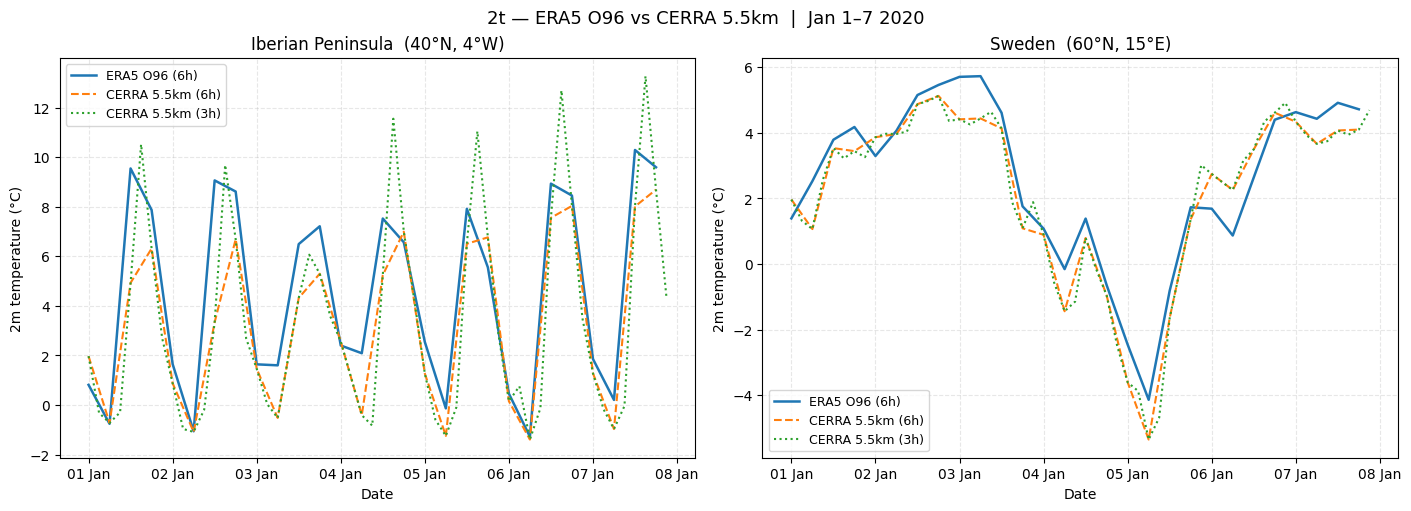

In [31]:
# Restrict all datasets to the CERRA 3h temporal window
CERRA_3H_START = "2020-01-01"
CERRA_3H_END   = "2020-01-07"

locations = [
    ("Iberian Peninsula", -4.0, 40.0),
    ("Sweden",            15.0, 60.0),
]

datasets = [
    ("ERA5 O96 (6h)",    ERA5_O96_ZARR,  "tab:blue",   "-",  1.8),
    ("CERRA 5.5km (6h)", CERRA_6H_ZARR,  "tab:orange", "--", 1.5),
    ("CERRA 5.5km (3h)", CERRA_3H_ZARR,  "tab:green",  ":",  1.5),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (loc_label, tlon, tlat) in zip(axes, locations):
    for ds_label, path, color, ls, lw in datasets:
        d = open_dataset(path, start=CERRA_3H_START, end=CERRA_3H_END)
        pt = nearest_grid_point(d.longitudes, d.latitudes, tlon, tlat)
        ts_dates = d.dates.astype("datetime64[ms]").astype("O")
        idx_2t = d.name_to_index["2t"]
        ts = d[:, idx_2t, 0, pt] - 273.15   # K → °C
        ax.plot(ts_dates, ts, color=color, linestyle=ls, linewidth=lw, label=ds_label)

    lat_str = f"{abs(tlat):.0f}°{'N' if tlat >= 0 else 'S'}"
    lon_str = f"{abs(tlon):.0f}°{'E' if tlon >= 0 else 'W'}"
    ax.set_title(f"{loc_label}  ({lat_str}, {lon_str})")
    ax.set_xlabel("Date")
    ax.set_ylabel("2m temperature (°C)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=9)

fig.suptitle("2t — ERA5 O96 vs CERRA 5.5km  |  Jan 1–7 2020", fontsize=13)
plt.show()

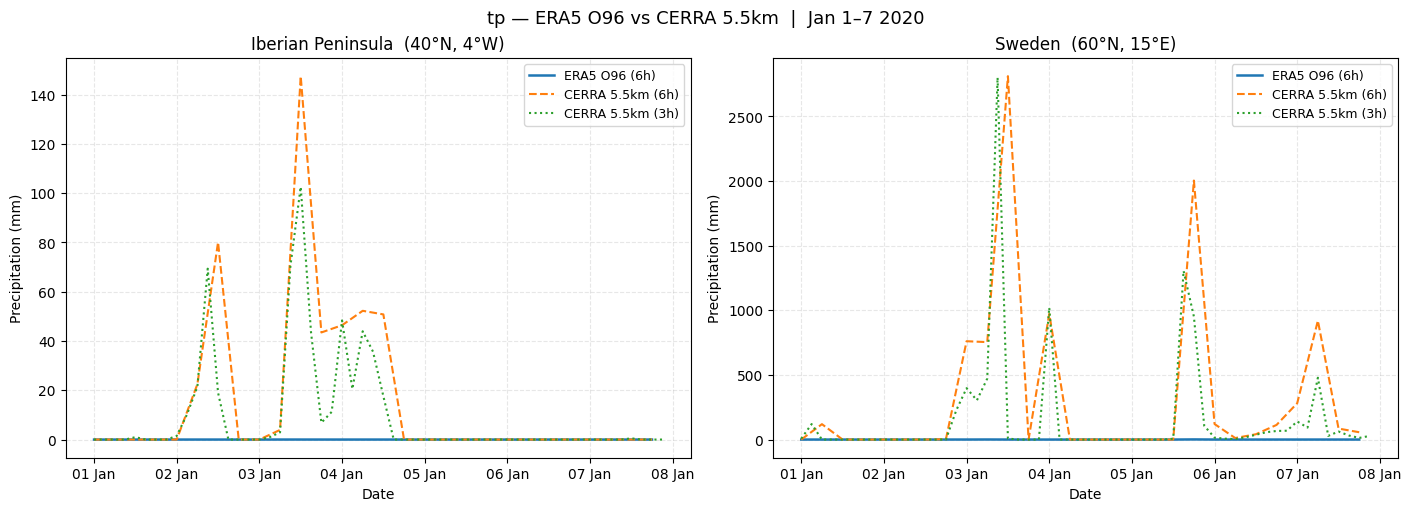

In [32]:
# Rainfall (tp) — same locations, same temporal window

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (loc_label, tlon, tlat) in zip(axes, locations):
    for ds_label, path, color, ls, lw in datasets:
        d = open_dataset(path, start=CERRA_3H_START, end=CERRA_3H_END)
        pt = nearest_grid_point(d.longitudes, d.latitudes, tlon, tlat)
        ts_dates = d.dates.astype("datetime64[ms]").astype("O")
        idx_tp = d.name_to_index["tp"]
        ts = d[:, idx_tp, 0, pt] * 1000   # m → mm
        ax.plot(ts_dates, ts, color=color, linestyle=ls, linewidth=lw, label=ds_label)

    lat_str = f"{abs(tlat):.0f}°{'N' if tlat >= 0 else 'S'}"
    lon_str = f"{abs(tlon):.0f}°{'E' if tlon >= 0 else 'W'}"
    ax.set_title(f"{loc_label}  ({lat_str}, {lon_str})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Precipitation (mm)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=9)

fig.suptitle("tp — ERA5 O96 vs CERRA 5.5km  |  Jan 1–7 2020", fontsize=13)
plt.show()

#### What the plots tell us

**2m temperature**

On the Iberian Peninsula, CERRA 5.5km at 3h resolution (green dotted) captures sharp intra-day peaks that reach up to ~13 °C, roughly 3–4 °C above the CERRA 6h values for the same timesteps. This is a **temporal resolution effect**: with 6h sampling the afternoon maximum is either missed entirely or averaged with cooler morning and evening values, flattening the diurnal cycle. ERA5 O96 (blue solid) tracks the synoptic trend but at systematically lower amplitude: the coarser ~100 km grid smooths out local heating driven by topography and land cover heterogeneity, which are particularly pronounced in the Iberian interior. Over Sweden, all three datasets agree much more closely. The terrain is flatter and the diurnal cycle is weaker in early January, so neither spatial nor temporal resolution drives a large spread.

**Precipitation**

ERA5 O96 registers near-zero precipitation at both locations throughout the period. This is not because it was dry in ERA5 globally, but because at ~100 km resolution the probability of a precipitation event landing on any single grid point is low, and the signal is smeared across many cells. CERRA 5.5km resolves convective and orographic features at a scale where individual events are concentrated on fewer grid points, producing realistic localised peaks (Iberian Peninsula ~Jan 3–4, Sweden ~Jan 3 and Jan 6).

The CERRA 3h accumulations are roughly **half** the CERRA 6h accumulations for the same events, exactly as expected, since both datasets record total precipitation within each time step and the 3h window captures half as much as the 6h window. This is not a discrepancy: summing two consecutive CERRA 3h values gives the corresponding CERRA 6h value. When comparing precipitation across datasets with different frequencies, always normalise to the same accumulation period (e.g. mm/h) before drawing conclusions about intensity differences.

### 2d — ERA5 from local NetCDF (1x1, 6h)

The same ERA5 January 2020 data as 2b, now delivered as **NetCDF** on a regular 1°×1° latitude/longitude grid — the typical shape of data downloaded from the CDS or pre-processed by a research group. Three files, one per variable group, each with four pressure levels (1000, 850, 500, 250 hPa) where relevant: `_sfc.nc`, `_pl.nc` and `_acc.nc`.

The recipe changes in four ways compared with 2b:

| | GRIB (2b) | NetCDF (2d) |
|---|---|---|
| Source key | `grib` / `grib-index` | `netcdf` |
| How anemoi finds date, level and variable | metadata stored in every GRIB message | **inferred** from coordinate names and CF attributes (`standard_name`, `units`, `positive`) |
| Variable names | GRIB short names (`10u`, `2t`, `2d`) | NetCDF names (`u10`, `t2m`, `d2m`) → renamed with a `pipe` |
| Accumulated fields (`tp`, `cp`) | `accumulate` + SQLite `grib-index` | converted to 6h **before** the recipe — `accumulate` does not read NetCDF |
| Grid | reduced Gaussian O96 (40 320 points) | regular 181 × 360 (65 160 points) |

The workflow has three steps: look at the files, convert precipitation to 6h accumulations, build the dataset.

In [33]:
import numpy as np
import xarray as xr

ERA5_LL_DIR = "data/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1"
ERA5_LL_PREFIX = f"{ERA5_LL_DIR}/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1"
ERA5_LL_CFG = "configs/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.yaml"
ERA5_LL_ACC6H = "data/derived/module-02/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1_acc6h.nc"
ERA5_LL_ZARR = "data/derived/module-02/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.zarr"

for part in ["sfc", "pl", "acc"]:
    f = xr.open_dataset(f"{ERA5_LL_PREFIX}_{part}.nc")
    print(f"_{part}.nc   dims: {dict(f.sizes)}")
    print(f"   variables:  {list(f.data_vars)}")
    step_h = np.unique(np.diff(f.valid_time.values)).astype("timedelta64[h]").astype(int).tolist()
    print(f"   time axis:  '{f.valid_time.name}' (standard_name='{f.valid_time.attrs['standard_name']}'), step = {step_h} h")
    if "pressure_level" in f:
        print(f"   levels:     {f.pressure_level.values} {f.pressure_level.attrs['units']} "
              f"(standard_name='{f.pressure_level.attrs['standard_name']}')")

_sfc.nc   dims: {'valid_time': 124, 'latitude': 181, 'longitude': 360}
   variables:  ['u10', 'v10', 'd2m', 't2m', 'lsm', 'msl', 'sdor', 'skt', 'slor', 'sp', 'tcw', 'z']
   time axis:  'valid_time' (standard_name='time'), step = [6] h
_pl.nc   dims: {'valid_time': 124, 'pressure_level': 4, 'latitude': 181, 'longitude': 360}
   variables:  ['q', 't', 'z', 'w', 'u', 'v']
   time axis:  'valid_time' (standard_name='time'), step = [6] h
   levels:     [1000.  850.  500.  250.] hPa (standard_name='air_pressure')
_acc.nc   dims: {'valid_time': 768, 'latitude': 181, 'longitude': 360}
   variables:  ['cp', 'tp']
   time axis:  'valid_time' (standard_name='time'), step = [1] h


#### Precipitation: from hourly values to 6h accumulations

`_acc.nc` stores `tp` and `cp` **hourly**: each value is the precipitation accumulated over the hour that *ends* at `valid_time`. The file starts on 2019-12-31 at 07:00 and runs for 32 days.

The `accumulate` source used in 2b cannot help here: it asks its source for fields by forecast base time and step and reads `startStep`/`endStep` from GRIB metadata, and NetCDF fields carry neither. With NetCDF you do the accumulation yourself, **before** the recipe runs:

> 6h accumulation ending at `T` = sum of the six hourly values ending at `T−5h, …, T`

This is the same window `(T−6h, T]` that `accumulate` builds in 2b. The **D−1 requirement** from 2b still applies: to get the window ending at 2020-01-01 00:00 the file must contain the hours of 31 December, which is why it starts at 07:00 on that day.

Two things are worth checking, because a rolling sum is only correct on a regular hourly axis and it is easy to be off by an hour:
1. the time axis really has a constant 1 h step;
2. the result matches an independent 6h `tp` — the O96 dataset built in 2b.

In [34]:
import numpy as np

acc = xr.open_dataset(f"{ERA5_LL_PREFIX}_acc.nc")

# 1. the rolling sum below is only valid on a regular hourly axis
steps = np.unique(np.diff(acc.valid_time.values))
assert len(steps) == 1 and steps[0] == np.timedelta64(1, "h"), steps

# 2. sum of the 6 hourly values ending at each valid_time, kept at the 6-hourly dates of the dataset
acc6 = acc[["cp", "tp"]].rolling(valid_time=6).sum()
acc6 = acc6.sel(valid_time=slice("2020-01-01T00:00", "2020-01-31T18:00"))
acc6 = acc6.sel(valid_time=acc6.valid_time.dt.hour.isin([0, 6, 12, 18]))
assert not acc6.to_array().isnull().any()          # D-1 hours are present, so no incomplete window

for var in acc6.data_vars:
    acc6[var].attrs.update(units="m", long_name=f"{acc[var].attrs['long_name']} (6h accumulation)")
acc6 = acc6.drop_vars("expver")                    # not needed downstream

acc6.to_netcdf(ERA5_LL_ACC6H)
print(f"Wrote {ERA5_LL_ACC6H}")
print(f"   {dict(acc6.sizes)}  first={acc6.valid_time.values[0]}  last={acc6.valid_time.values[-1]}")

Wrote data/derived/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1_acc6h.nc
   {'valid_time': 124, 'latitude': 181, 'longitude': 360}  first=2020-01-01T00:00:00.000000000  last=2020-01-31T18:00:00.000000000


In [35]:
# Check against the 6h `tp` of the O96 dataset from 2b (different grids, so compare global means)
ds_o96 = open_dataset(ERA5_O96_ZARR)
tp_o96 = np.asarray(ds_o96[:, ds_o96.name_to_index["tp"], 0, :]).mean(axis=1)    # O96 points ~ equal area

weights = np.cos(np.deg2rad(acc.latitude))                                        # regular grid: weight by cos(lat)
hourly_6h_sum = acc.tp.rolling(valid_time=6).sum()

print(f"mean tp   O96 (from GRIB accumulate): {tp_o96.mean():.3e} m   |   NetCDF 6h sum: "
      f"{acc6.tp.weighted(weights).mean().item():.3e} m\n")
print("Correlation of the global-mean series when the 6h window is shifted:")
for shift in [-1, 0, 1]:
    shifted = hourly_6h_sum.shift(valid_time=shift).sel(valid_time=slice("2020-01-01T00:00", "2020-01-31T18:00"))
    shifted = shifted.sel(valid_time=shifted.valid_time.dt.hour.isin([0, 6, 12, 18]))
    series = shifted.weighted(weights).mean(("latitude", "longitude")).values
    print(f"   window ending at T{shift:+d}h : {np.corrcoef(series, tp_o96)[0, 1]:.3f}")

mean tp   O96 (from GRIB accumulate): 7.630e-04 m   |   NetCDF 6h sum: 7.419e-04 m

Correlation of the global-mean series when the 6h window is shifted:
   window ending at T-1h : 0.956
   window ending at T+0h : 0.981
   window ending at T+1h : 0.953


#### The recipe

The recipe joins three NetCDF sources plus the forcings — compare it with the 2b recipe:

- `netcdf` on `_pl.nc` — instantaneous pressure-level fields. anemoi recognises the `pressure_level` dimension (`standard_name: air_pressure`, `units: hPa`, `positive: down`) as the level, so the variables come out as `q_500`, `t_850`, … exactly as with GRIB. It is listed first so that the forcings can use it as their `template`.
- `pipe` on `_sfc.nc` — the first use of **`pipe`** in this module: a source followed by a filter. The `rename` filter maps the NetCDF names to the anemoi names (`u10` → `10u`, `v10` → `10v`, `d2m` → `2d`, `t2m` → `2t`).
- `netcdf` on the 6h `tp`/`cp` file produced above.
- `constants` — the same nine forcings as in 2b.

Two details that are easy to get wrong:
- **`rename` is keyed by the metadata field:** `rename: {param: {u10: 10u}}`. The shorthand `rename: {u10: 10u}` is accepted but silently does nothing — the variable simply keeps its NetCDF name. Always check `ds.variables` after building.
- **`options: {drop_variables: [expver]}`** is passed straight to `xarray.open_dataset`. The files carry an `expver` coordinate that anemoi does not understand; it is harmless but makes the reader print a long message for every date.

In [36]:
print(Path(ERA5_LL_CFG).read_text())

name: demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1

description: Small dataset for training purposes, created from ERA5 data in NetCDF format (1x1 degree regular lat/lon)

attribution: ECMWF/C3S

license: CC-BY-4.0

dates:
  start: 2020-01-01T00:00:00
  end: 2020-01-31T18:00:00
  frequency: 6h

build:
  group_by: daily

statistics:
  allow_nans: true

input:
  join:
  # NetCDF containing pressure level variables
  - netcdf:
      path: data/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1_pl.nc
      options:
        drop_variables: [expver]
  # NetCDF containing surface variables: NetCDF names -> anemoi (GRIB) names
  - pipe:
    - netcdf:
        path: data/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1_sfc.nc
        options:
          drop_variables: [expver]
    - rename:
        param:
          u10: 10u
          v10: 10v
          d2m: 2d
          t2

In [37]:
!anemoi-datasets create {ERA5_LL_CFG} {ERA5_LL_ZARR} --overwrite

2026-09-25 11:27:08 INFO 🎬 Task init((),{}) starting
2026-09-25 11:27:08 INFO Running task: init, recipe: configs/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.zarr', 'trace': False}
2026-09-25 11:27:08 INFO Loading recipe from YAML file at configs/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.yaml
2026-09-25 11:27:08 INFO Creating dataset with format: gridded
2026-09-25 11:27:08 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.zarr.work_dir
2026-09-25 11:27:08 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.zarr'.
2026-09-25 11:27:08 INFO Initialising dataset creation.
2026-09-25 11:27:08 INFO Dataset path: data/derived/demo-ea-an-oper-00

In [38]:
!anemoi-datasets inspect {ERA5_LL_ZARR}

📦 Path          : data/derived/demo-ea-an-oper-0001-cdsapi-ll1x1-202001-202001-6h-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-01-31 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : None
🌎 Field shape: [181, 360]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 124 × 47 × 1 × 65,160 (1.4 GiB)
💽 Size       : 686.7 MiB (686.7 MiB)
📁 Files      : 151

   Index │ Variable       │          Min │         Max │        Mean │       Stdev
   ──────┼────────────────┼──────────────┼─────────────┼─────────────┼────────────
       0 │ 10u            │     -28.0757 │     34.9633 │   -0.113785 │     5.49118
       1 │ 10v            │     -30.8832 │     25.3809 │   -0.149765 │     4.61168
       2 │ 2d             │      211.496 │     302.805 │     273.327 │     19.3852
       3 │ 2t             │      215.175 │     320.038 │     277.427 │     19.8891
       4 │ cos_julian_day │     0.912493 │           1 │     0.97051 │   0.0264244
       5 │ c

Shape:        (124, 47, 1, 65160)
Field shape:  (181, 360)   (regular lat/lon: the flat grid dimension can be reshaped)
Dates:        2020-01-01T00:00:00 -> 2020-01-31T18:00:00, frequency 6:00:00

Same variables as the O96 dataset: True (47 variables)
Renamed surface variables present: ['10u', '10v', '2d', '2t']


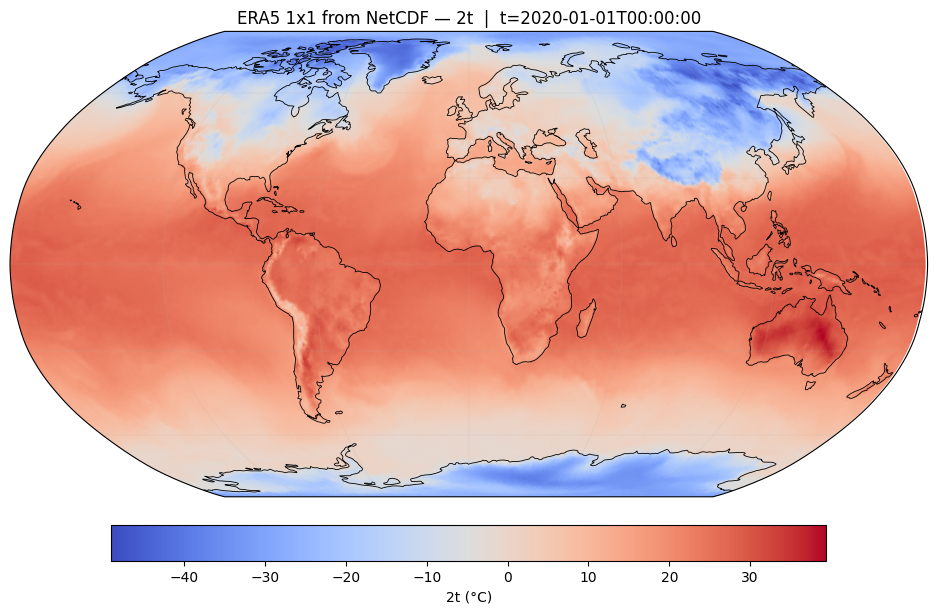

In [100]:
ds_ll = open_dataset(ERA5_LL_ZARR)
print(f"Shape:        {ds_ll.shape}")
print(f"Field shape:  {ds_ll.field_shape}   (regular lat/lon: the flat grid dimension can be reshaped)")
print(f"Dates:        {ds_ll.dates[0]} -> {ds_ll.dates[-1]}, frequency {ds_ll.frequency}")

# Same 47 variable names as the GRIB-based O96 dataset from 2b -> the renames and the level detection worked
print(f"\nSame variables as the O96 dataset: {set(ds_ll.variables) == set(ds_o96.variables)} ({len(ds_ll.variables)} variables)")
print("Renamed surface variables present:", [v for v in ["10u", "10v", "2d", "2t"] if v in ds_ll.variables])

# Same plot_variable/tripcolor rendering as the O48 global map in Section 1 (cell 14) —
# works on a regular grid too, so every spatial plot in the notebook stays visually consistent.
fig, ax = plot_variable(ds_ll, "2t", projection=ccrs.Robinson(central_longitude=0), convert_kelvin=True)
ax.set_title(f"ERA5 1x1 from NetCDF — 2t  |  t={ds_ll.dates[0]}")
plt.show()

#### What to remember about NetCDF sources

- **anemoi infers, GRIB tells.** For NetCDF, dates, levels and variables come from coordinate names and CF attributes. When a file is not read as expected, look at its coordinates first (`xarray.open_dataset(...)`).
- **`rename` takes the metadata key first** (`param:`), otherwise it silently does nothing.
- **`accumulate` is for GRIB (`grib-index`) and MARS only.** For NetCDF, convert accumulations to the target window beforehand, and check what a `step` or `valid_time` really means before trusting it — here a one-hour shift is enough to lower the agreement with the reference.
- **Files converted from GRIB with `cfgrib` may keep forecast-style labels** (`time` as forecast reference time, a `step` and a second `valid_time` coordinate) that anemoi cannot interpret. That is the case for the raw ERA5 NetCDFs of the hackathon, and it is handled with `options: {drop_variables: [...]}` and a `patch` in the recipe.

### 2e — Subsetting an existing zarr as source

Each subsetting dimension — time, variables, and grid — is covered with two complementary approaches:

| Approach | Command | Result |
|---|---|---|
| **Recipe-level** | `anemoi-datasets create` | New, physically smaller zarr — baked in permanently |
| **Read-time** | `open_dataset(path, ...)` | Lazy view over the original zarr — nothing written to disk |

Use the recipe-level approach when you will train repeatedly from the same subset (saves I/O every epoch). Use `open_dataset` for one-off exploration.

#### Time subsetting

**Recipe-level:** create one zarr per date window — the configs in `configs/o48_subset/` define `dates:` and reference the full O48 zarr as `input:`.

**Read-time:** pass `start=`, `end=`, or `frequency=` to `open_dataset` for a lazy temporal slice or downsample — no new zarr is written.

#### Monthly subsets of the ERA5 O48 dataset

We create six monthly zarr stores from the full ERA5 O48 dataset (Jan–Jun 2020). Each config in `configs/o48_subset/` is self-contained, it carries the date range, metadata, and the `input:` block pointing at the full zarr. Output names follow the same convention as the config files.

The six zarrs produced here are reused in the cells below and in later sections.

In [40]:
# January 2020
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202001-6h-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202001-6h-v1.zarr \
    --overwrite

2026-09-25 11:28:32 INFO 🎬 Task init((),{}) starting
2026-09-25 11:28:32 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202001-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202001-6h-v1.zarr', 'trace': False}
2026-09-25 11:28:32 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202001-6h-v1.yaml
2026-09-25 11:28:32 INFO Creating dataset with format: gridded
2026-09-25 11:28:32 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202001-6h-v1.zarr.work_dir
2026-09-25 11:28:32 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202001-6h-v1.zarr'.
2026-09-25 11:28:32 INFO Initialising dataset creation.
2026-09-25 11:28:32 INFO Dataset path: data/derived/demo-ea-an-oper-

In [41]:
# February 2020
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202002-202002-6h-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202002-202002-6h-v1.zarr \
    --overwrite

2026-09-25 11:28:43 INFO 🎬 Task init((),{}) starting
2026-09-25 11:28:43 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202002-202002-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202002-202002-6h-v1.zarr', 'trace': False}
2026-09-25 11:28:43 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202002-202002-6h-v1.yaml
2026-09-25 11:28:43 INFO Creating dataset with format: gridded
2026-09-25 11:28:43 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202002-202002-6h-v1.zarr.work_dir
2026-09-25 11:28:43 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202002-202002-6h-v1.zarr'.
2026-09-25 11:28:43 INFO Initialising dataset creation.
2026-09-25 11:28:43 INFO Dataset path: data/derived/demo-ea-an-oper-

In [42]:
# March 2020
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202003-202003-6h-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202003-202003-6h-v1.zarr \
    --overwrite

2026-09-25 11:28:52 INFO 🎬 Task init((),{}) starting
2026-09-25 11:28:52 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202003-202003-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202003-202003-6h-v1.zarr', 'trace': False}
2026-09-25 11:28:52 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202003-202003-6h-v1.yaml
2026-09-25 11:28:52 INFO Creating dataset with format: gridded
2026-09-25 11:28:52 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202003-202003-6h-v1.zarr.work_dir
2026-09-25 11:28:52 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202003-202003-6h-v1.zarr'.
2026-09-25 11:28:52 INFO Initialising dataset creation.
2026-09-25 11:28:52 INFO Dataset path: data/derived/demo-ea-an-oper-

In [43]:
# April 2020
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202004-202004-6h-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202004-202004-6h-v1.zarr \
    --overwrite

2026-09-25 11:29:00 INFO 🎬 Task init((),{}) starting
2026-09-25 11:29:00 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202004-202004-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202004-202004-6h-v1.zarr', 'trace': False}
2026-09-25 11:29:00 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202004-202004-6h-v1.yaml
2026-09-25 11:29:00 INFO Creating dataset with format: gridded
2026-09-25 11:29:00 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202004-202004-6h-v1.zarr.work_dir
2026-09-25 11:29:00 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202004-202004-6h-v1.zarr'.
2026-09-25 11:29:00 INFO Initialising dataset creation.
2026-09-25 11:29:00 INFO Dataset path: data/derived/demo-ea-an-oper-

In [44]:
# May 2020
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202005-202005-6h-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202005-202005-6h-v1.zarr \
    --overwrite

2026-09-25 11:29:10 INFO 🎬 Task init((),{}) starting
2026-09-25 11:29:10 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202005-202005-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202005-202005-6h-v1.zarr', 'trace': False}
2026-09-25 11:29:10 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202005-202005-6h-v1.yaml
2026-09-25 11:29:10 INFO Creating dataset with format: gridded
2026-09-25 11:29:10 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202005-202005-6h-v1.zarr.work_dir
2026-09-25 11:29:10 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202005-202005-6h-v1.zarr'.
2026-09-25 11:29:10 INFO Initialising dataset creation.
2026-09-25 11:29:10 INFO Dataset path: data/derived/demo-ea-an-oper-

In [45]:
# June 2020
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202006-202006-6h-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202006-202006-6h-v1.zarr \
    --overwrite

2026-09-25 11:29:20 INFO 🎬 Task init((),{}) starting
2026-09-25 11:29:20 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202006-202006-6h-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202006-202006-6h-v1.zarr', 'trace': False}
2026-09-25 11:29:20 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202006-202006-6h-v1.yaml
2026-09-25 11:29:20 INFO Creating dataset with format: gridded
2026-09-25 11:29:20 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202006-202006-6h-v1.zarr.work_dir
2026-09-25 11:29:20 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202006-202006-6h-v1.zarr'.
2026-09-25 11:29:20 INFO Initialising dataset creation.
2026-09-25 11:29:20 INFO Dataset path: data/derived/demo-ea-an-oper-

In [46]:
# Integer year vs full datetime string — both work
ds_q1_int = open_dataset(ERA5_O48, start=2020, end="2020-03")
ds_q1_str = open_dataset(ERA5_O48, start="2020-01-01", end="2020-03-31T18:00:00")

print(f"Integer:  {ds_q1_int.dates[0]} → {ds_q1_int.dates[-1]}  ({len(ds_q1_int.dates)} steps)")
print(f"String:   {ds_q1_str.dates[0]} → {ds_q1_str.dates[-1]}  ({len(ds_q1_str.dates)} steps)")

Integer:  2020-01-01T00:00:00 → 2020-03-31T18:00:00  (364 steps)
String:   2020-01-01T00:00:00 → 2020-03-31T18:00:00  (364 steps)


In [47]:
# Downsample from 6h to 24h — picks every 4th timestep
ds_daily = open_dataset(ERA5_O48, frequency="24h")
print(f"Original (6h):  {len(ds.dates)} steps")
print(f"Downsampled (24h): {len(ds_daily.dates)} steps")
print(f"First dates: {ds_daily.dates[:4]}")

Original (6h):  728 steps
Downsampled (24h): 182 steps
First dates: ['2020-01-01T00:00:00' '2020-01-02T00:00:00' '2020-01-03T00:00:00'
 '2020-01-04T00:00:00']


In [48]:
# Gotcha: end="2020" snaps to the last valid timestep of 2020
# For a 6h dataset that is 2020-12-31T18:00, not 2020-12-31T23:00
ds_end_6h = open_dataset(ERA5_O48, end="2020")
print(f"end='2020' on 6h dataset → last date: {ds_end_6h.dates[-1]}")
# Always verify ds.dates[-1] matches your intention when using year-only end strings

end='2020' on 6h dataset → last date: 2020-06-30T18:00:00


#### Variable subsetting

**Recipe-level:** `select:` / `drop:` in the config produce a new zarr containing only the chosen variables.

**Read-time:** `open_dataset(path, select=[...])`, `drop=[...]`, `rename={...}`, and `rescale={...}` apply lazily; the underlying zarr is untouched.

##### Example 1 — surface variables

Select the 6 standard surface variables (`2t`, `2d`, `msl`, `sp`, `10u`, `10v`), producing a physically smaller zarr.

In [49]:
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.zarr \
    --overwrite

2026-09-25 11:29:28 INFO 🎬 Task init((),{}) starting
2026-09-25 11:29:28 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.zarr', 'trace': False}
2026-09-25 11:29:28 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.yaml
2026-09-25 11:29:28 INFO Creating dataset with format: gridded
2026-09-25 11:29:28 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.zarr.work_dir
2026-09-25 11:29:28 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.zarr'.
2026-09-25 11:29:28 INFO Initialising dataset creation.
2026-09-25 11:29:28 INFO Dataset path: data/deri

In [50]:
!anemoi-datasets inspect data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.zarr

ds_sfc = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.zarr")
print("Surface variables:", ds_sfc.variables)

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-sfc-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-06-30 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O48
🌎 Field shape: [10944]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 728 × 6 × 1 × 10,944 (182.4 MiB)
💽 Size       : 117.8 MiB (117.8 MiB)
📁 Files      : 753

   Index │ Variable │      Min │     Max │       Mean │   Stdev
   ──────┼──────────┼──────────┼─────────┼────────────┼────────
       0 │ 10u      │ -31.1339 │ 27.8938 │  -0.568336 │ 5.43208
       1 │ 10v      │ -34.5802 │ 29.6575 │ -0.0927517 │ 4.51046
       2 │ 2d       │      198 │ 302.976 │    282.147 │ 16.3366
       3 │ 2t       │  201.357 │ 320.262 │    287.222 │ 16.5117
       4 │ msl      │  92725.8 │  106800 │     101150 │  1111.6
       5 │ sp       │  50213.9 │  106661 │    98439.1 │  7038.3
   ──────┴──────────┴──────────┴─────────┴────────────┴────────
🔋 Dataset ready, las

##### Example 2 — pressure-level variables

Select all pressure-level variables (`t`, `q`, `u`, `v`, `z` at 1000/850/500/250 hPa — 20 variables total).

In [51]:
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.zarr \
    --overwrite

2026-09-25 11:29:42 INFO 🎬 Task init((),{}) starting
2026-09-25 11:29:42 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.zarr', 'trace': False}
2026-09-25 11:29:42 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.yaml
2026-09-25 11:29:42 INFO Creating dataset with format: gridded
2026-09-25 11:29:42 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.zarr.work_dir
2026-09-25 11:29:42 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.zarr'.
2026-09-25 11:29:42 INFO Initialising dataset creation.
2026-09-25 11:29:42 INFO Dataset path: data/derived/d

In [52]:
!anemoi-datasets inspect data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.zarr

ds_pl = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.zarr")
print("Pressure-level variables:", ds_pl.variables)

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-pl-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-06-30 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O48
🌎 Field shape: [10944]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 728 × 20 × 1 × 10,944 (607.9 MiB)
💽 Size       : 413.7 MiB (413.7 MiB)
📁 Files      : 753

   Index │ Variable │          Min │        Max │        Mean │       Stdev
   ──────┼──────────┼──────────────┼────────────┼─────────────┼────────────
       0 │ q_1000   │        1e-08 │  0.0247477 │  0.00956179 │  0.00612576
       1 │ q_250    │ -4.33519e-05 │ 0.00123064 │ 8.59728e-05 │ 9.37692e-05
       2 │ q_500    │        1e-08 │ 0.00784141 │  0.00119153 │  0.00133164
       3 │ q_850    │  1.58571e-07 │  0.0208699 │  0.00621539 │  0.00449401
       4 │ t_1000   │      228.688 │    319.196 │     288.305 │     14.0997
       5 │ t_250    │      197.494 │    247.214 │     226.541 │ 

In [53]:
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr \
    --overwrite

2026-09-25 11:30:06 INFO 🎬 Task init((),{}) starting
2026-09-25 11:30:06 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr', 'trace': False}
2026-09-25 11:30:06 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.yaml
2026-09-25 11:30:06 INFO Creating dataset with format: gridded
2026-09-25 11:30:06 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr.work_dir
2026-09-25 11:30:06 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr'.
2026-09-25 11:30:06 INFO Initialising dataset creation.
2026-09-25 11

In [54]:
!anemoi-datasets inspect data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-06-30 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O48
🌎 Field shape: [10944]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 728 × 34 × 1 × 10,944 (1 GiB)
💽 Size       : 661.8 MiB (661.8 MiB)
📁 Files      : 753

   Index │ Variable │          Min │        Max │        Mean │       Stdev
   ──────┼──────────┼──────────────┼────────────┼─────────────┼────────────
       0 │ 10u      │     -31.1339 │    27.8938 │   -0.568336 │     5.43208
       1 │ 10v      │     -34.5802 │    29.6575 │  -0.0927517 │     4.51046
       2 │ 2d       │          198 │    302.976 │     282.147 │     16.3366
       3 │ 2t       │      201.357 │    320.262 │     287.222 │     16.5117
       4 │ cp       │            0 │  0.0720558 │  0.00037526 │  0.00126728
       5 │ lsm      │            0 │          1 │    0.28768

In [55]:
ds_drop = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr")
print("Variables after drop:", ds_drop.variables)

Variables after drop: ['10u', '10v', '2d', '2t', 'cp', 'lsm', 'msl', 'q_1000', 'q_250', 'q_500', 'q_850', 'sdor', 'skt', 'slor', 'sp', 't_1000', 't_250', 't_500', 't_850', 'tcw', 'tp', 'u_1000', 'u_250', 'u_500', 'u_850', 'v_1000', 'v_250', 'v_500', 'v_850', 'z', 'z_1000', 'z_250', 'z_500', 'z_850']


##### `select` ordering: list vs set

Passing `select` as a **list** preserves the order you specify. Passing it as a **set** preserves the dataset's original variable order. Here we mix sfc and pl variables from the two examples above to make the contrast visible.

In [56]:
# select as a list → preserves YOUR order
ds_list = open_dataset(ERA5_O48, select=["msl", "t_850", "2t", "z_500"])
print("List order:  ", ds_list.variables)

# select as a set → preserves DATASET order
ds_set = open_dataset(ERA5_O48, select={"msl", "t_850", "2t", "z_500"})
print("Set order:   ", ds_set.variables)

List order:   ['msl', 't_850', '2t', 'z_500']
Set order:    ['2t', 'msl', 't_850', 'z_500']


In [57]:
# drop and rename
ds_renamed = open_dataset(ERA5_O48, select=["2t", "msl"], rename={"2t": "t2m", "msl": "slp"})
print("Renamed variables:", ds_renamed.variables)

Renamed variables: ['t2m', 'slp']


In [58]:
# rescale: convert 2t from Kelvin to Celsius — explicit (a, b) coefficients: rescaled = a*x + b
ds_celsius = open_dataset(ERA5_O48, select=["2t"], rescale={"2t": (1, -273.15)})

idx = ds_celsius.name_to_index["2t"]
print(f"Before rescale: mean={ds.statistics['mean'][ds.name_to_index['2t']]:.2f} K")
print(f"After rescale:  mean={ds_celsius.statistics['mean'][idx]:.2f} °C")

Before rescale: mean=287.22 K
After rescale:  mean=14.07 °C


#### Grid subsetting

**Recipe-level:** `area: [N, W, S, E]` in the config crops the grid permanently into a new zarr.

**Read-time:** `open_dataset(path, area=(...))` or `thinning=N` return a lazy view over the original grid — useful for quick regional exploration.

In [59]:
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.zarr \
    --overwrite

2026-09-25 11:30:34 INFO 🎬 Task init((),{}) starting
2026-09-25 11:30:34 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.zarr', 'trace': False}
2026-09-25 11:30:34 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.yaml
2026-09-25 11:30:34 INFO Creating dataset with format: gridded
2026-09-25 11:30:34 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.zarr.work_dir
2026-09-25 11:30:34 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.zarr'.
2026-09-25 11:30:34 INFO Initialising dataset creation.
2026-09-25 11:30:34 INFO Dataset path: data

In [60]:
!anemoi-datasets inspect data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.zarr

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-06-30 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O48
🌎 Field shape: [130]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 728 × 43 × 1 × 130 (15.5 MiB)
💽 Size       : 11.1 MiB (11.1 MiB)
📁 Files      : 753

   Index │ Variable       │         Min │        Max │        Mean │       Stdev
   ──────┼────────────────┼─────────────┼────────────┼─────────────┼────────────
       0 │ 10u            │    -17.1709 │    22.6026 │    0.356699 │     4.08622
       1 │ 10v            │    -17.8212 │    18.3924 │    -0.60601 │     3.84007
       2 │ 2d             │     247.318 │    295.312 │       280.4 │     6.04523
       3 │ 2t             │     252.612 │    318.526 │     286.759 │     6.04935
       4 │ cos_julian_day │   -0.800336 │          1 │    0.239709 │    0.589267
       5 │ cos_latitude   │    0.67

Global grid points:  10944
Cropped grid points: 130


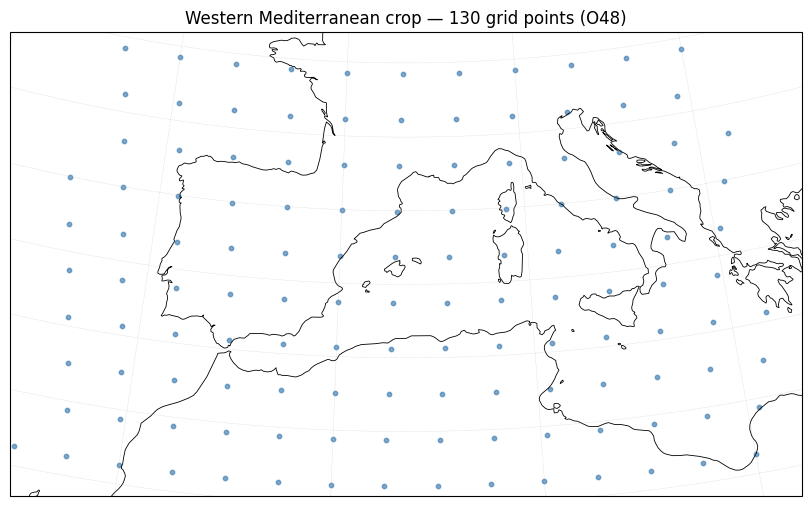

In [61]:
ds_wmed = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-v1.zarr")
print(f"Global grid points:  {len(ds.latitudes)}")
print(f"Cropped grid points: {len(ds_wmed.latitudes)}")

WMED_EXTENT = [-15, 22, 30, 48]

fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={"projection": wmed_proj},
                       constrained_layout=True)
ax.set_extent(WMED_EXTENT, crs=ccrs.PlateCarree())
ax.coastlines(resolution="50m", linewidth=0.6)
ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5, linestyle="--")
ax.scatter(ds_wmed.longitudes, ds_wmed.latitudes, s=10, color="steelblue",
           transform=ccrs.PlateCarree(), alpha=0.7)
ax.set_title(
    f"Western Mediterranean crop — {len(ds_wmed.latitudes)} grid points (O48)"
)
plt.show()

In [62]:
# thinning: keep every Nth grid point. thinning is only supported on regular lat/lon grids (`field_shape` is 2D).
# The O48/O96 reduced Gaussian datasets used in this module have an unstructured 1D grid, for the thinning operation we use CERRA dataset. 
ds_cerra = open_dataset(CERRA_3H_ZARR)
ds_cerra_thin = open_dataset(CERRA_3H_ZARR, thinning=4)
print(f"Original:  {len(ds_cerra.latitudes):>6} grid points")
print(f"Thinning=4: {len(ds_cerra_thin.latitudes):>6} grid points")

Original:  1142761 grid points
Thinning=4:  71824 grid points


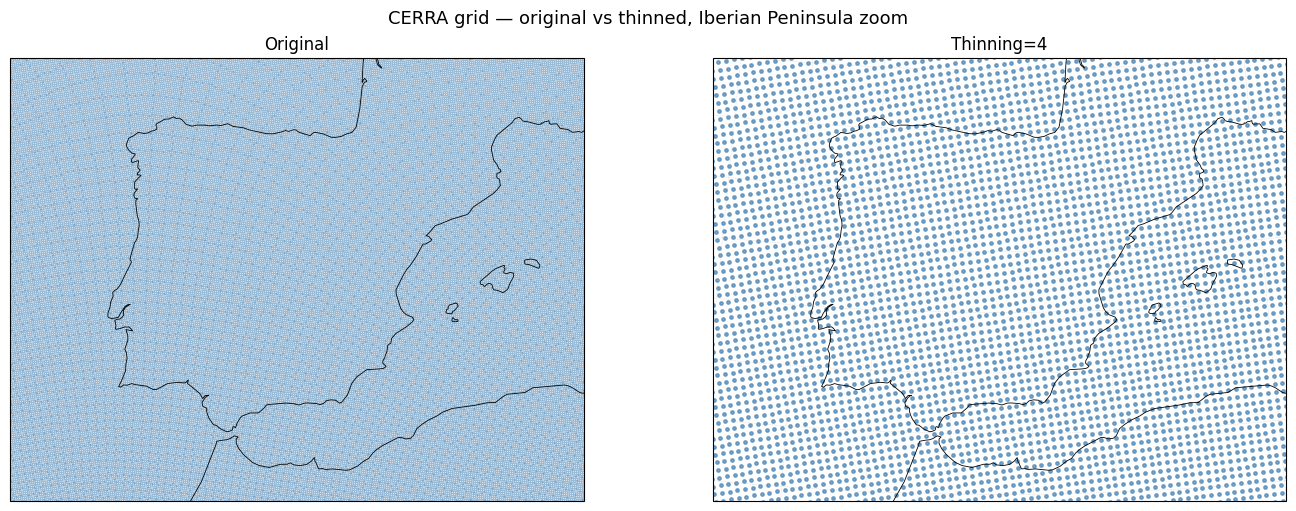

In [63]:
iberia_proj = ccrs.LambertConformal(
    central_longitude=-3.5,
    central_latitude=40.0,
    standard_parallels=(36, 44),
)
IBERIA_EXTENT = [-12, 5, 34, 45]

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         subplot_kw={"projection": iberia_proj},
                         constrained_layout=True)

configs = [
    (ds_cerra,      0.2,  f"Original"),
    (ds_cerra_thin, 6, f"Thinning=4"),
]

for ax, (ds_plot, s, title) in zip(axes, configs):
    ax.set_extent(IBERIA_EXTENT, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", linewidth=0.6)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5, linestyle="--")
    ax.scatter(ds_plot.longitudes, ds_plot.latitudes,
               s=s, color="steelblue", alpha=0.7, transform=ccrs.PlateCarree())
    ax.set_title(title)

fig.suptitle("CERRA grid — original vs thinned, Iberian Peninsula zoom", fontsize=13)
plt.show()

Europe crop: 454 grid points


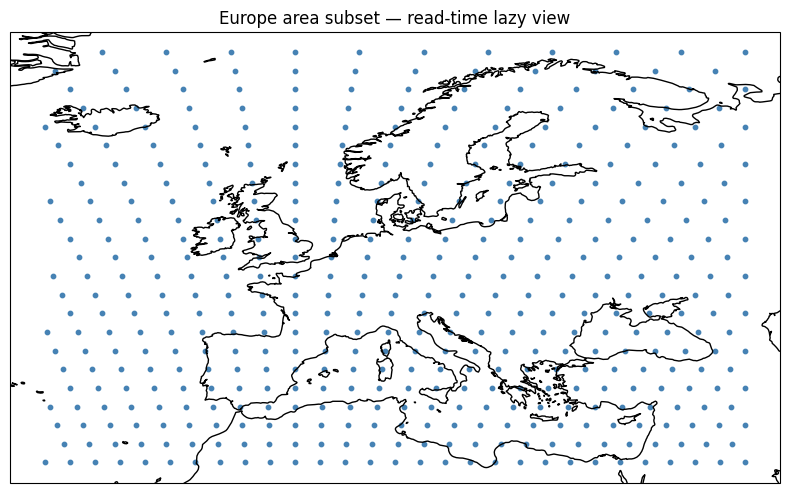

In [64]:
# area: read-time crop to Europe [N, W, S, E] — lazy view, zarr untouched
ds_europe = open_dataset(ERA5_O48, area=(72, -25, 30, 45))
print(f"Europe crop: {len(ds_europe.latitudes)} grid points")

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.scatter(ds_europe.longitudes, ds_europe.latitudes, s=10, color="steelblue",
           transform=ccrs.PlateCarree())
ax.coastlines()
ax.set_title("Europe area subset — read-time lazy view")
plt.tight_layout()
plt.show()

#### Combined subsetting

Multiple subsetting operations (`area` + `select`) can be stacked in a single recipe block. The result is the intersection of all constraints baked into one zarr.

In [65]:
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.zarr \
    --overwrite

2026-09-25 11:30:58 INFO 🎬 Task init((),{}) starting
2026-09-25 11:30:58 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.zarr', 'trace': False}
2026-09-25 11:30:58 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.yaml
2026-09-25 11:30:58 INFO Creating dataset with format: gridded
2026-09-25 11:30:58 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.zarr.work_dir
2026-09-25 11:30:58 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.zarr'.
2026-09-25 11:30:58 INFO Initialising dataset creation.
2026-09-

In [66]:
!anemoi-datasets inspect data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.zarr

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-06-30 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O48
🌎 Field shape: [130]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 728 × 4 × 1 × 130 (1.4 MiB)
💽 Size       : 1.3 MiB (1.3 MiB)
📁 Files      : 753

   Index │ Variable │      Min │     Max │     Mean │   Stdev
   ──────┼──────────┼──────────┼─────────┼──────────┼────────
       0 │ 10u      │ -17.1709 │ 22.6026 │ 0.356699 │ 4.08622
       1 │ 10v      │ -17.8212 │ 18.3924 │ -0.60601 │ 3.84007
       2 │ 2t       │  252.612 │ 318.526 │  286.759 │ 6.04935
       3 │ msl      │  98566.5 │  104791 │   101956 │ 735.549
   ──────┴──────────┴──────────┴─────────┴──────────┴────────
🔋 Dataset ready, last update 2 hours ago.
📊 Statistics ready.



In [67]:
ds_comb = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-wmed-select-v1.zarr")
print(f"Variables:   {ds_comb.variables}")
print(f"Grid points: {len(ds_comb.latitudes)}")

Variables:   ['10u', '10v', '2t', 'msl']
Grid points: 130


---
## Section 3 — Modular Creation: `init` / `load` / `finalise`

> "This guide shows how to create a dataset incrementally. This is useful when you have a large dataset that you want to load in parts, to avoid running out of memory. Because parts can be loaded in parallel, this can also speed up the process."  
> — *anemoi-datasets documentation*

**Why `create` doesn't scale:** it processes all date groups in a single sequential process — one CPU, no parallelism, all-or-nothing. For a full ERA5 dataset (43 years, O96, 6h) that would take weeks.

The modular workflow decomposes the job:

| Step | Command | What it does | Parallel? |
|---|---|---|---|
| 1 | `init` | Allocates the zarr store, embeds the recipe | No (once) |
| 2 | `load --parts K/N` | Fills one date partition | Yes — N workers in parallel |
| 3 | `finalise` | Consolidates chunks, computes statistics | No (once) |
| 4 | `cleanup` | Removes temporary files | No (once) |

**Parts are 1-based:** `--parts 1/4`, `2/4`, `3/4`, `4/4` — not 0-based.  
With `group_by: daily` and 31 days in January 2020, 4 parts cover ~8 days each.

In [68]:
INCREMENTAL_ZARR = "data/derived/module-02/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr"

# Step 1: allocate the zarr store (--overwrite makes this cell re-runnable)
!anemoi-datasets init {ERA5_O96_CFG} {INCREMENTAL_ZARR} --overwrite

2026-09-25 11:31:06 INFO 🎬 Task init((),{}) starting
2026-09-25 11:31:06 INFO Running task: init, recipe: configs/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.yaml, kwargs: {'rich': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr', 'overwrite': True, 'check_name': False, 'trace': False}
2026-09-25 11:31:06 INFO Loading recipe from YAML file at configs/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1.yaml
2026-09-25 11:31:06 INFO Creating dataset with format: gridded
2026-09-25 11:31:06 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr.work_dir
2026-09-25 11:31:06 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr'.
2026-09-25 11:31:06 INFO Initialising dataset creation.
2026-09-25 11:31:06 INFO Dataset path: data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h

In [69]:
# Store allocated but not yet populated - prints Error for the statistics of the dataset
!anemoi-datasets inspect {INCREMENTAL_ZARR}

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-01-31 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O96
🌎 Field shape: [40320]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 124 × 47 × 1 × 40,320 (896.4 MiB)

2026-09-25 11:31:13 ERROR Error inspecting zarr file 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr': 'mean'
<class 'anemoi.datasets.commands.inspect.Version0_14'>
Traceback (most recent call last):
  File "/home/fdainell/Documents/climate-data-ai-anemoi/.venv/bin/anemoi-datasets", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/home/fdainell/Documents/climate-data-ai-anemoi/.venv/lib/python3.12/site-packages/anemoi/datasets/__main__.py", line 33, in main
    cli_main(__version__, __doc__, COMMANDS)
  File "/home/fdainell/Documents/climate-data-ai-anemoi/.venv/lib/python3.12/site

In [70]:
# Step 2a: load the first quarter of date groups (~days 1–8, parts are 1-based)
!anemoi-datasets load {INCREMENTAL_ZARR} --parts 1/4

2026-09-25 11:31:14 INFO 🎬 Task load((),{}) starting
2026-09-25 11:31:14 INFO Running task: load, recipe: None, kwargs: {'rich': False, 'parts': ['1/4'], 'path': 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr', 'trace': False}
2026-09-25 11:31:14 INFO Loading recipe from Zarr store at data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr
2026-09-25 11:31:14 INFO Creating dataset with format: gridded
2026-09-25 11:31:14 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr.work_dir
2026-09-25 11:31:14 INFO Running parts: [0, 1, 2, 3, 4, 5, 6, 7]
📁: ('PATH', 'data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1_sfc.grib')
2026-09-25 11:31:17 INFO Registering data at path: ('input', 'join', '0', 'grib')
📁: ('PATH', 'data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper

In [71]:
# Step 2b: load the second quarter (~days 9–16)
!anemoi-datasets load {INCREMENTAL_ZARR} --parts 2/4

2026-09-25 11:31:39 INFO 🎬 Task load((),{}) starting
2026-09-25 11:31:39 INFO Running task: load, recipe: None, kwargs: {'rich': False, 'parts': ['2/4'], 'path': 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr', 'trace': False}
2026-09-25 11:31:39 INFO Loading recipe from Zarr store at data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr
2026-09-25 11:31:39 INFO Creating dataset with format: gridded
2026-09-25 11:31:39 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr.work_dir
2026-09-25 11:31:39 INFO Running parts: [8, 9, 10, 11, 12, 13, 14, 15]
📁: ('PATH', 'data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1_sfc.grib')
2026-09-25 11:31:42 INFO Registering data at path: ('input', 'join', '0', 'grib')
📁: ('PATH', 'data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-a

In [72]:
# Steps 2c–2d: load remaining quarters — in production these run simultaneously on separate HPC nodes
!anemoi-datasets load {INCREMENTAL_ZARR} --parts 3/4
!anemoi-datasets load {INCREMENTAL_ZARR} --parts 4/4

2026-09-25 11:32:04 INFO 🎬 Task load((),{}) starting
2026-09-25 11:32:04 INFO Running task: load, recipe: None, kwargs: {'rich': False, 'parts': ['3/4'], 'path': 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr', 'trace': False}
2026-09-25 11:32:04 INFO Loading recipe from Zarr store at data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr
2026-09-25 11:32:04 INFO Creating dataset with format: gridded
2026-09-25 11:32:04 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr.work_dir
2026-09-25 11:32:04 INFO Running parts: [16, 17, 18, 19, 20, 21, 22, 23]
📁: ('PATH', 'data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1_sfc.grib')
2026-09-25 11:32:06 INFO Registering data at path: ('input', 'join', '0', 'grib')
📁: ('PATH', 'data/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-v1/demo-ea

In [73]:
# Step 3: consolidate chunks and compute statistics
!anemoi-datasets finalise {INCREMENTAL_ZARR}

2026-09-25 11:32:51 INFO 🎬 Task finalise((),{}) starting
2026-09-25 11:32:51 INFO Running task: finalise, recipe: None, kwargs: {'rich': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr', 'trace': False}
2026-09-25 11:32:51 INFO Loading recipe from Zarr store at data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr
2026-09-25 11:32:51 INFO Creating dataset with format: gridded
2026-09-25 11:32:51 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr.work_dir
2026-09-25 11:32:51 INFO Finalising dataset.
2026-09-25 11:32:51 INFO Running statistics computation.
2026-09-25 11:32:51 INFO Loading precomputed statistics from data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr.work_dir (31 files)
Adjusting partial statistics: 100%|█████████| 31/31 [00:00<00:00, 646882.71it/s]
2026-09-25 11:32:51 INFO 

In [74]:
# Step 4: remove temporary part files
!anemoi-datasets cleanup {INCREMENTAL_ZARR}

2026-09-25 11:32:52 INFO 🎬 Task cleanup((),{}) starting
2026-09-25 11:32:52 INFO Running task: cleanup, recipe: None, kwargs: {'rich': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr'}
2026-09-25 11:32:52 INFO Loading recipe from Zarr store at data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr
2026-09-25 11:32:52 INFO Creating dataset with format: gridded
2026-09-25 11:32:52 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr.work_dir
2026-09-25 11:32:52 INFO 🏁 Task cleanup((),{}) completed (0:00:00.076029)
2026-09-25 11:32:52 INFO Create step 'cleanup' completed in 76.1 milliseconds


In [75]:
# Step 5: inspect the dataset just created
!anemoi-datasets inspect {INCREMENTAL_ZARR}

📦 Path          : data/derived/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr
🔢 Format version: 0.14.0

📅 Start      : 2020-01-01 00:00
📅 End        : 2020-01-31 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : O96
🌎 Field shape: [40320]

📅 Data start : None
📅 Data end   : None

📐 Shape      : 124 × 47 × 1 × 40,320 (896.4 MiB)
💽 Size       : 477.7 MiB (477.7 MiB)
📁 Files      : 158

   Index │ Variable       │          Min │         Max │         Mean │       Stdev
   ──────┼────────────────┼──────────────┼─────────────┼──────────────┼────────────
       0 │ 10u            │     -27.6433 │     32.2532 │    -0.718168 │     5.43849
       1 │ 10v            │     -30.4588 │     23.8539 │    -0.356976 │     4.42549
       2 │ 2d             │      212.273 │     302.533 │      282.382 │     15.7432
       3 │ 2t             │       215.65 │      319.61 │      286.948 │     15.9745
       4 │ cos_julian_day │     0.912493 │           1 │      0.97051 │   0.0264244

#### Verify: incremental == `create`

The incremental build should produce an identical dataset to the single-step `create` command — same shape, same variables, and matching statistics.

In [76]:
ds_create      = open_dataset(ERA5_O96_ZARR)
ds_incremental = open_dataset(INCREMENTAL_ZARR)

print(f"create shape:      {ds_create.shape}")
print(f"incremental shape: {ds_incremental.shape}")
print(f"variables match:   {ds_create.variables == ds_incremental.variables}")

for key in ["mean", "stdev"]:
    match = np.allclose(ds_create.statistics[key], ds_incremental.statistics[key], rtol=1e-5)
    print(f"statistics['{key}'] match: {match}")

create shape:      (124, 47, 1, 40320)
incremental shape: (124, 47, 1, 40320)
variables match:   True
statistics['mean'] match: True
statistics['stdev'] match: True


---
## Section 4 — Combining, Missing Dates, and Normalisation

**Goal:** Combine multiple datasets with `open_dataset`, handle missing timesteps, and apply the standard normalisation pattern used in anemoi-training.

All operations here are lazy read-time views — nothing is written to disk. For all subsetting operations (time, variable, grid) see Section 2e.

### Combining datasets

`concat` (time) and `join` (variables) can be performed either at creation time via a recipe — producing a new zarr on disk — or lazily at read time via `open_dataset`.

#### Concat — stitching time periods

Concat assembles datasets with the **same variables** over adjacent date ranges into a single continuous zarr. Here we concatenate the 6 monthly O48 subsets and verify the result matches the original 6-month dataset.

In [77]:
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.zarr \
    --overwrite

2026-09-25 11:32:53 INFO 🎬 Task init((),{}) starting
2026-09-25 11:32:53 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.zarr', 'trace': False}
2026-09-25 11:32:53 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.yaml
2026-09-25 11:32:54 INFO Creating dataset with format: gridded
2026-09-25 11:32:54 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.zarr.work_dir
2026-09-25 11:32:54 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.zarr'.
2026-09-25 11:32:54 INFO Initialising dataset creation.
2026-09-25 11:32:54 INFO Dataset 

In [78]:
# Read-time approach: pass monthly datasets — open_dataset auto-detects concat
MONTHLY = [
    f"data/derived/module-02/demo-ea-an-oper-0001-mars-o48-2020{m:02d}-2020{m:02d}-6h-v1.zarr"
    for m in range(1, 7)
]
ds_concat_open   = open_dataset(*MONTHLY)
ds_concat_create = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-concat-v1.zarr")
ds_o48           = open_dataset(ERA5_O48)   # original 6-month reference

print(f"open_dataset:    {ds_concat_open.dates[0]} → {ds_concat_open.dates[-1]}  ({len(ds_concat_open.dates)} steps)")
print(f"create (concat): {ds_concat_create.dates[0]} → {ds_concat_create.dates[-1]}  ({len(ds_concat_create.dates)} steps)")
print(f"original O48:    {ds_o48.dates[0]} → {ds_o48.dates[-1]}  ({len(ds_o48.dates)} steps)")
print()
print(f"Dates match (create vs original):     {list(ds_concat_create.dates) == list(ds_o48.dates)}")
print(f"Variables match (create vs original): {ds_concat_create.variables == ds_o48.variables}")

open_dataset:    2020-01-01T00:00:00 → 2020-06-30T18:00:00  (728 steps)
create (concat): 2020-01-01T00:00:00 → 2020-06-30T18:00:00  (728 steps)
original O48:    2020-01-01T00:00:00 → 2020-06-30T18:00:00  (728 steps)

Dates match (create vs original):     True
Variables match (create vs original): True


#### Join — merging variable sets

Join assembles datasets with **different variables** over the same date range. Here we join the `sfc` and `pl` subsets and compare the result with the noforcings dataset: both lack forcing variables, but noforcings retains additional land-surface and accumulated variables (`lsm`, `skt`, `tp`, `cp`, etc.).

In [79]:
!anemoi-datasets create \
    configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.yaml \
    data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.zarr \
    --overwrite

2026-09-25 11:33:13 INFO 🎬 Task init((),{}) starting
2026-09-25 11:33:13 INFO Running task: init, recipe: configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.yaml, kwargs: {'version': False, 'debug': False, 'rich': False, 'overwrite': True, 'recompute_statistics': False, 'path': 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.zarr', 'trace': False}
2026-09-25 11:33:13 INFO Loading recipe from YAML file at configs/o48_subset/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.yaml
2026-09-25 11:33:13 INFO Creating dataset with format: gridded
2026-09-25 11:33:13 INFO Using work dir: /home/fdainell/Documents/climate-data-ai-anemoi/data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.zarr.work_dir
2026-09-25 11:33:13 WARNING Overwriting existing dataset at 'data/derived/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.zarr'.
2026-09-25 11:33:13 INFO Initialising dataset creation.
2026-09-25 11:33:13 INFO Dataset path: data

In [80]:
# Read-time approach: ds_sfc and ds_pl are already defined in Section 2
ds_join_open   = open_dataset(ds_sfc, ds_pl)
ds_join_create = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-join-v1.zarr")
ds_noforcings  = open_dataset("data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr")

print(f"Join (open):     {ds_join_open.variables}")
print(f"Join (create):   {ds_join_create.variables}")
print()
join_set  = set(ds_join_create.variables)
nofrc_set = set(ds_noforcings.variables)
print(f"In noforcings only ({len(nofrc_set - join_set)} vars): {sorted(nofrc_set - join_set)}")
print(f"Shared ({len(join_set & nofrc_set)} vars) — all sfc+pl vars are present in noforcings")

Join (open):     ['10u', '10v', '2d', '2t', 'msl', 'sp', 'q_1000', 'q_250', 'q_500', 'q_850', 't_1000', 't_250', 't_500', 't_850', 'u_1000', 'u_250', 'u_500', 'u_850', 'v_1000', 'v_250', 'v_500', 'v_850', 'z_1000', 'z_250', 'z_500', 'z_850']
Join (create):   ['10u', '10v', '2d', '2t', 'msl', 'q_1000', 'q_250', 'q_500', 'q_850', 'sp', 't_1000', 't_250', 't_500', 't_850', 'u_1000', 'u_250', 'u_500', 'u_850', 'v_1000', 'v_250', 'v_500', 'v_850', 'z_1000', 'z_250', 'z_500', 'z_850']

In noforcings only (8 vars): ['cp', 'lsm', 'sdor', 'skt', 'slor', 'tcw', 'tp', 'z']
Shared (26 vars) — all sfc+pl vars are present in noforcings


In [81]:
# Missing dates
print("Missing dates in ERA5 O48:", ds.missing)

# fill_missing_dates interpolates or fills missing rows at read time
# WARNING: do NOT use fill_missing_dates in anemoi-training configs —
# anemoi-training handles missing dates internally. Adding this flag there
# would corrupt the temporal alignment between input and target steps.
ds_filled = open_dataset(ERA5_O48, fill_missing_dates="interpolate")
print(f"After fill_missing_dates='interpolate': {len(ds_filled.dates)} steps")

Missing dates in ERA5 O48: set()
After fill_missing_dates='interpolate': 728 steps


### Normalisation pattern

anemoi-datasets stores per-variable mean and stdev. The standard normalisation used in training is `(x − mean) / stdev` applied per variable.

Normalised shape: (43, 1, 10944)


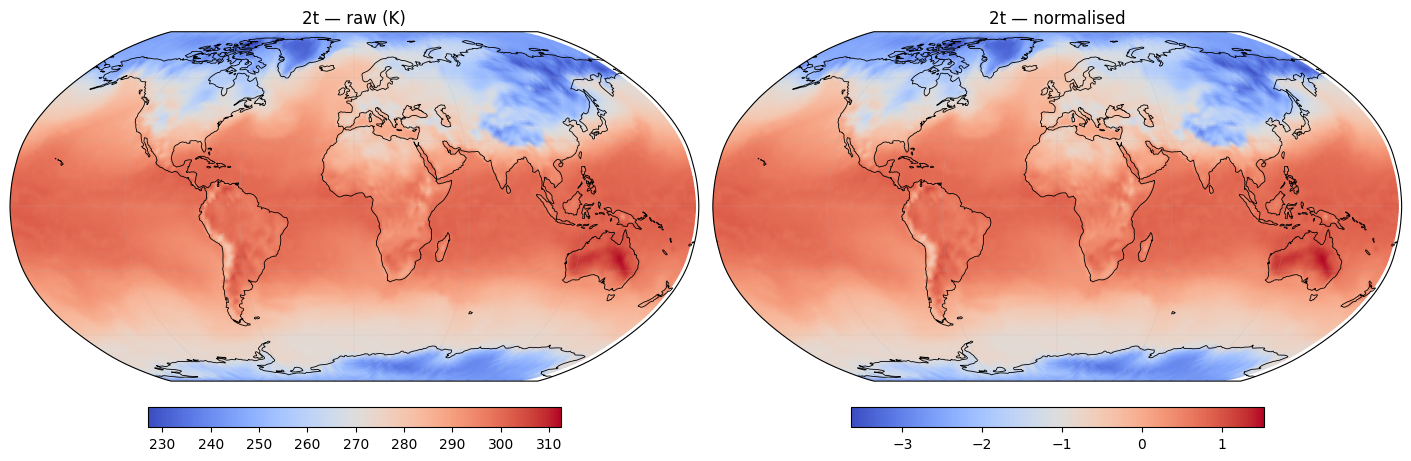

In [82]:
sample = ds[0]   # shape: (n_variables, n_ensemble_members, n_gridpoints)
mean   = ds.statistics["mean"][:, np.newaxis, np.newaxis]   # broadcast over ensemble + grid
std    = ds.statistics["stdev"][:, np.newaxis, np.newaxis]

normalised = (sample - mean) / std

assert not np.any(np.isnan(normalised)), "NaNs in normalised output — check allow_nans in recipe"
print(f"Normalised shape: {normalised.shape}")

# Visual check: 2t before and after normalisation
idx_2t = ds.name_to_index["2t"]
proj = ccrs.Robinson()

# Build once — same grid for both panels
tri = _build_projected_triangulation(ds.longitudes, ds.latitudes, proj)

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          subplot_kw={"projection": proj},
                          constrained_layout=True)

for ax, values, title in [
    (axes[0], sample[idx_2t, 0, :], "2t — raw (K)"),
    (axes[1], normalised[idx_2t, 0, :], "2t — normalised"),
]:
    mesh = ax.tripcolor(tri, values, shading="gouraud", cmap="coolwarm")
    ax.coastlines(resolution="110m", linewidth=0.6)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5, linestyle="--")
    ax.set_global()
    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.6)
    ax.set_title(title)

plt.show()

---
## Section 5 — Validation and Best Practices

In [83]:
# Validate a finished dataset — checks shape, statistics, missing dates, metadata
# Output symbols: ✅ pass · ⚠️ warning · 💣 error · 💥 fatal
!anemoi-datasets validate {ERA5_O96_ZARR}


Training Methods:
-----------------

✅ __getitem__              : Success.
✅ __len__                  : Success.
✅ latitudes                : Success.
✅ longitudes               : Success.
✅ metadata                 : Success.
✅ missing                  : Success.
✅ name_to_index            : Success.
✅ shape                    : Success.
✅ statistics               : Success.
✅ supporting_arrays        : Success.
✅ variables                : Success.

Extra Training Methods:
-----------------------

💥 statistics_tendencies    : 'statistics_tendencies_6h_mean'.

Debugging Methods:
------------------

✅ plot                     : Success.
                              ⚠️ Validation for plot not implemented. Result: <class 'cartopy.mpl.geoaxes.GeoAxes'>
✅ to_index                 : Success.
                              ⚠️ Validation for to_index not implemented. Result: <class 'tuple'>
✅ tree                     : Success.
                              ⚠️ Validation for tree not impleme

In [84]:
# Compare two datasets — checks that shape, variables, and statistics match
!anemoi-datasets compare {ERA5_O96_ZARR} data/derived/module-02/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr

2026-09-25 11:33:34 WARNING Comparing Zarr metadata and statistics, not data contents. Use --data to compare data contents.

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------



In [85]:
# Compare two datasets — checks also the data contents
!anemoi-datasets compare --data {ERA5_O96_ZARR} data/derived/module-02/demo-ea-an-oper-0001-mars-o96-202001-202001-6h-incremental-v1.zarr

2026-09-25 11:33:35 INFO Comparing large arrays zarr.data using 8 workers
Comparing zarr.data: 100%|██████████████████████| 1/1 [00:09<00:00,  9.04s/part]

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------



In [86]:
# Compare two datasets that are different - an Error is returned
!anemoi-datasets compare data/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1.zarr data/derived/module-02/demo-ea-an-oper-0001-mars-o48-202001-202006-6h-noforcings-v1.zarr

2026-09-25 11:33:45 WARNING Comparing Zarr metadata and statistics, not data contents. Use --data to compare data contents.

--------------------------------------------------------------------------------
❗ 🏷️ metadata.chunks.1 reference=43 (<class 'int'>) != actual=34 (<class 'int'>)
❗ metadata.constant_fields lengths are different reference=8 != actual=4
❗ 🏷️ metadata.description reference='O48 ERA5 demo dataset, first 6 months of 2020, subset from the 2020-2021 zarr' (<class 'str'>) != actual='Dynamic forcings dropped (sin/cos encodings, insolation) from demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1' (<class 'str'>)
❗ 🏷️ metadata.recipe.description reference='O48 ERA5 demo dataset, first 6 months of 2020, subset from the 2020-2021 zarr' (<class 'str'>) != actual='Dynamic forcings dropped (sin/cos encodings, insolation) from demo-ea-an-oper-0001-mars-o48-202001-202006-6h-v1' (<class 'str'>)
❗ 🏷️ metadata.recipe.input.anemoi-dataset.dataset reference='data/demo-ea-an-oper-0001-ma

### Dataset naming convention

Format: `purpose-content-source-resolution-start-end-frequency-version`

| Field | Example | Notes |
|---|---|---|
| purpose | `aifs` | model family or project name |
| content | `ea-an-oper-0001` | `ea` = ERA5, `an` = analysis, `oper` = operational, `0001` = expver |
| source | `mars` or `cdsapi` | data origin |
| resolution | `o96`, `5p5km` | grid identifier |
| start–end | `1979-2022` | year range |
| frequency | `6h` | timestep |
| version | `v6` | dataset version |

Example: `aifs-ea-an-oper-0001-mars-o96-1979-2022-6h-v6`

**Rules:** lowercase, hyphens only — no underscores, no dots.

### Top 10 gotchas

1. `--parts` is **1-based** (parts `1/N` through `N/N`, not `0/N`)
2. Never set `date`/`time`/`step` inside a source block — only in `dates:`
3. Multi-level variables are named `t_850`, `z_500`, etc. — use `anemoi-datasets inspect` to confirm exact names
4. NaN value ≠ missing date — each must be declared explicitly (`allow_nans` vs `missing`)
5. `end="2020"` snaps to the last valid timestep of 2020, not midnight — always verify `ds.dates[-1]`
6. `select=["list"]` preserves your order; `select={"set"}` preserves dataset order
7. `number` (ensemble member in MARS) is 1-based; `member` in anemoi is 0-based
8. `concat` statistics default to the first dataset — use `statistics=` to override
9. Plain `grib` source **silently drops** accumulated/forecast fields — always use `accumulate` + `grib-index` for `tp`, `cp`, radiation
10. For CERRA `accumulate`: the built-in MARS shortcut covers only 1 run/day — use the explicit `[[0,"0-6"], [6,"0-6"], ...]` availability list for 4×/day CDS downloads

In [87]:
# Live demo: gotcha 5 (end year) and gotcha 6 (select order)

# Gotcha 5
ds_end = open_dataset(ERA5_O48, end="2020")
print(f"end='2020' last date: {ds_end.dates[-1]}")
print(f"  — note: this is 18:00, not 23:00, because the dataset frequency is 6h")
print()

# Gotcha 6
ds_list_order = open_dataset(ERA5_O48, select=["msl", "2t", "10u"])
ds_set_order  = open_dataset(ERA5_O48, select={"msl", "2t", "10u"})
print(f"select=['msl','2t','10u'] → {ds_list_order.variables}  (your order)")
print(f"select={{{'msl','2t','10u'}}} → {ds_set_order.variables}  (dataset order)")

end='2020' last date: 2020-06-30T18:00:00
  — note: this is 18:00, not 23:00, because the dataset frequency is 6h

select=['msl','2t','10u'] → ['msl', '2t', '10u']  (your order)
select={('msl', '2t', '10u')} → ['10u', '2t', 'msl']  (dataset order)
